# NCA GEDI Waveform, Quality-Flag, and AOI Diagnostic

This notebook inspects the **spatial-only NCA GEDI L1B/L2A subsets** created by the repacking workflow.

The objective is deliberately diagnostic rather than prescriptive:

1. inventory the subset archive and confirm L1B/L2A pairing,
2. inspect available beam-level and shot-level science datasets,
3. summarize GEDI quality/degradation flags **before filtering**,
4. pair L1B and L2A records by `shot_number`,
5. examine AOI-scale spatial coverage and beam representation,
6. quantify several interpretable consistency diagnostics,
7. plot full receive and transmit waveforms for representative shots,
8. compare waveforms among good, degraded, low-sensitivity, and algorithmically unusual shots.

No quality filter is imposed globally in this notebook.

That is intentional: the spatial-only archive lets us evaluate whether standard GEDI quality criteria are appropriate for this dryland, low-stature vegetation system before removing information.

### Important interpretation

These diagnostics are not interchangeable:

- **L2A `quality_flag`**: a product-level validity/usefulness flag for the selected L2A solution.
- **`degrade_flag`**: indicates geolocation/pointing degradation conditions.
- **`sensitivity`**: waveform sensitivity / penetration capability, not geometric accuracy.
- **`surface_flag`**: indicates whether `elev_lowestmode` is within 300 m of the reference DEM/MSS; this is a broad plausibility flag.
- **L1B↔L2A horizontal separation**: product-coordinate consistency for the same shot, not independent external geolocation truth.
- **GEDI elevation minus reference DEM**: useful as an AOI diagnostic, but should not be treated as an automatic cleaning rule.

References:
- GEDI L1B/L2A V2 tutorials: NASA/LP DAAC GEDI-Data-Resources.
- GEDI L2A User Guide / Waveform ATBD.


In [1]:
from pathlib import Path
import re
import warnings

import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

warnings.filterwarnings("ignore", category=RuntimeWarning)


## 1. Paths and configuration


In [2]:
ROOT = Path(r"A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A")

SUBSET_ROOT = ROOT / "NCA_spatial_subset_h5"
L1B_DIR = SUBSET_ROOT / "GEDI01_B"
L2A_DIR = SUBSET_ROOT / "GEDI02_A"

AOI_PATH = Path(r"A:\NCA_DATA\templates\NCA_NAD83UTM11N.shp")

# Number of example waveforms to plot per diagnostic class.
N_WAVEFORMS_PER_CLASS = 4

# Reproducible sampling.
RANDOM_SEED = 42

print("Subset root:", SUBSET_ROOT)
print("L1B subset:", L1B_DIR)
print("L2A subset:", L2A_DIR)
print("AOI:", AOI_PATH)

assert L1B_DIR.exists(), f"Missing L1B subset directory: {L1B_DIR}"
assert L2A_DIR.exists(), f"Missing L2A subset directory: {L2A_DIR}"
assert AOI_PATH.exists(), f"Missing AOI: {AOI_PATH}"


Subset root: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5
L1B subset: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\GEDI01_B
L2A subset: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\GEDI02_A
AOI: A:\NCA_DATA\templates\NCA_NAD83UTM11N.shp


## 2. Pair L1B and L2A subset granules

The repacker preserved paired granules using the shared orbit/sub-orbit key:

`O#####_##_T#####_##`

We first verify that the analytical subset archive still has one-to-one L1B/L2A pairing.


In [3]:
ORBIT_KEY_RE = re.compile(r"(O\d{5}_\d{2}_T\d{5}_\d{2})")

def orbit_key(path_or_name):
    name = Path(path_or_name).name
    m = ORBIT_KEY_RE.search(name)
    if m is None:
        raise ValueError(f"Could not parse GEDI orbit key: {name}")
    return m.group(1)

l1b_files = sorted(L1B_DIR.glob("*.h5"))
l2a_files = sorted(L2A_DIR.glob("*.h5"))

l1b_lookup = {orbit_key(p): p for p in l1b_files}
l2a_lookup = {orbit_key(p): p for p in l2a_files}

all_keys = sorted(set(l1b_lookup) | set(l2a_lookup))

pair_table = pd.DataFrame({
    "granule_key": all_keys,
    "l1b": [l1b_lookup.get(k) for k in all_keys],
    "l2a": [l2a_lookup.get(k) for k in all_keys],
})
pair_table["paired"] = pair_table["l1b"].notna() & pair_table["l2a"].notna()

print(f"L1B subset files: {len(l1b_files):,}")
print(f"L2A subset files: {len(l2a_files):,}")
print(f"Paired granules:  {pair_table['paired'].sum():,}")
print(f"Unpaired records: {(~pair_table['paired']).sum():,}")

display(pair_table.head(20))

if not pair_table["paired"].all():
    display(pair_table.loc[~pair_table["paired"]])


L1B subset files: 189
L2A subset files: 189
Paired granules:  189
Unpaired records: 0


,granule_key,l1b,l2a,paired
0,O02061_02_T00905_02,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,True
1,O02168_02_T05021_02,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,True
2,O02202_03_T00174_02,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,True
3,O02275_02_T03292_02,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,True
4,O02309_03_T01444_02,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,True
5,O02382_02_T01869_02,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,True
6,O02416_03_T03984_02,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,True
7,O02489_02_T00140_02,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,True
8,O02657_02_T05679_02,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,True
9,O02718_02_T01058_02,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA...,True


## 3. Generic HDF5 structure helpers

GEDI is hierarchical and some variables differ slightly in location among products/releases.  
These helpers:

- list beams,
- recursively inventory datasets,
- locate the first available candidate dataset,
- read only shot-oriented 1-D vectors when lengths match `shot_number`.

This keeps the diagnostic tolerant to small path differences without silently coercing incompatible arrays.


In [4]:
BEAM_RE = re.compile(r"^BEAM\d{4}$")

def list_beams(h5):
    return sorted(k for k in h5.keys() if BEAM_RE.match(k))

def walk_datasets(group, prefix=""):
    rows = []
    for name, obj in group.items():
        path = f"{prefix}/{name}" if prefix else name
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "path": path,
                "shape": obj.shape,
                "dtype": str(obj.dtype),
            })
        elif isinstance(obj, h5py.Group):
            rows.extend(walk_datasets(obj, path))
    return rows

def first_existing(group, candidates):
    for path in candidates:
        try:
            obj = group[path]
            if isinstance(obj, h5py.Dataset):
                return obj, path
        except Exception:
            pass
    return None, None

def read_1d(group, candidates, n=None):
    ds, used = first_existing(group, candidates)
    if ds is None:
        return None, None
    arr = np.asarray(ds)
    if arr.ndim != 1:
        return None, used
    if n is not None and len(arr) != n:
        return None, used
    return arr, used

def safe_numeric(arr):
    if arr is None:
        return None
    arr = np.asarray(arr)
    if arr.dtype.kind in "biufc":
        return arr
    return None


## 4. Inspect the structure of one paired granule


In [5]:
paired = pair_table.loc[pair_table["paired"]].reset_index(drop=True)
if paired.empty:
    raise RuntimeError("No paired subset granules found.")

example_l1b = paired.loc[0, "l1b"]
example_l2a = paired.loc[0, "l2a"]

print("Example L1B:", example_l1b.name)
print("Example L2A:", example_l2a.name)

with h5py.File(example_l1b, "r") as h5:
    print("\nL1B beams:", list_beams(h5))
    l1b_inventory = pd.DataFrame(walk_datasets(h5))

with h5py.File(example_l2a, "r") as h5:
    print("L2A beams:", list_beams(h5))
    l2a_inventory = pd.DataFrame(walk_datasets(h5))

print("\nL1B dataset inventory:")
display(l1b_inventory.head(100))

print("\nL2A dataset inventory:")
display(l2a_inventory.head(100))


Example L1B: GEDI01_B_2019114135421_O02061_02_T00905_02_005_01_V002.h5
Example L2A: GEDI02_A_2019114135421_O02061_02_T00905_02_003_01_V002.h5

L1B beams: ['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']
L2A beams: ['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']

L1B dataset inventory:


,path,shape,dtype
0,BEAM0000/all_samples_sum,"(870,)",uint32
1,BEAM0000/ancillary/master_time_epoch,"(1,)",float64
2,BEAM0000/ancillary/mean_samples,"(1,)",int64
3,BEAM0000/ancillary/smoothing_width,"(1,)",float64
4,BEAM0000/beam,"(870,)",uint16
5,BEAM0000/channel,"(870,)",uint8
6,BEAM0000/delta_time,"(870,)",float64
7,BEAM0000/geolocation/altitude_instrument,"(870,)",float64
8,BEAM0000/geolocation/altitude_instrument_error,"(870,)",float32
9,BEAM0000/geolocation/bounce_time_offset_bin0,"(870,)",float64



L2A dataset inventory:


,path,shape,dtype
0,BEAM0000/ancillary/l2a_alg_count,"(1,)",uint8
1,BEAM0000/beam,"(870,)",uint16
2,BEAM0000/channel,"(870,)",uint8
3,BEAM0000/degrade_flag,"(870,)",uint8
4,BEAM0000/delta_time,"(870,)",float64
5,BEAM0000/digital_elevation_model,"(870,)",float32
6,BEAM0000/digital_elevation_model_srtm,"(870,)",float32
7,BEAM0000/elev_highestreturn,"(870,)",float32
8,BEAM0000/elev_lowestmode,"(870,)",float32
9,BEAM0000/elevation_bias_flag,"(870,)",uint8


## 5. Extract AOI shot tables from every subset file

The L2A table is the main science/quality table.  
The L1B table provides waveform indexing and independent product-coordinate fields.

Candidate fields are read only when they are present and shot-aligned.


In [6]:
L2A_FIELDS = {
    "latitude_l2a": ["lat_lowestmode", "geolocation/latitude_lowestmode", "geolocation/lat_lowestmode"],
    "longitude_l2a": ["lon_lowestmode", "geolocation/longitude_lowestmode", "geolocation/lon_lowestmode"],
    "quality_flag": ["quality_flag"],
    "degrade_flag": ["degrade_flag", "geolocation/degrade_flag"],
    "sensitivity": ["sensitivity"],
    "surface_flag": ["surface_flag"],
    "elevation_bias_flag": ["elevation_bias_flag"],
    "selected_algorithm": ["selected_algorithm"],
    "selected_mode": ["selected_mode"],
    "selected_mode_flag": ["selected_mode_flag"],
    "num_detectedmodes": ["num_detectedmodes"],
    "elev_lowestmode": ["elev_lowestmode"],
    "elev_highestreturn": ["elev_highestreturn"],
    "digital_elevation_model": ["digital_elevation_model", "geolocation/digital_elevation_model"],
    "solar_elevation": ["solar_elevation", "geolocation/solar_elevation"],
    "delta_time": ["delta_time"],
    "beam_type": ["beam_type", "geolocation/beam_type"],
    "channel": ["channel", "geolocation/channel"],
}

L1B_FIELDS = {
    "latitude_l1b": ["geolocation/latitude_bin0", "latitude_bin0"],
    "longitude_l1b": ["geolocation/longitude_bin0", "longitude_bin0"],
    "elevation_bin0": ["geolocation/elevation_bin0", "elevation_bin0"],
    "elevation_lastbin": ["geolocation/elevation_lastbin", "elevation_lastbin"],
    "digital_elevation_model_l1b": ["geolocation/digital_elevation_model", "digital_elevation_model"],
    "degrade_flag_l1b": ["geolocation/degrade_flag", "degrade_flag"],
    "geolocation_quality_flag": ["geolocation/quality_flag"],
    "stale_return_flag": ["stale_return_flag"],
    "rx_sample_start_index": ["rx_sample_start_index"],
    "rx_sample_count": ["rx_sample_count"],
    "tx_sample_start_index": ["tx_sample_start_index"],
    "tx_sample_count": ["tx_sample_count"],
    "rx_energy": ["rx_energy"],
    "tx_energy": ["tx_energy"],
    "rx_maxamp": ["rx_maxamp"],
    "rx_mean": ["rx_mean"],
    "rx_sd": ["rx_sd"],
    "noise_mean_corrected": ["noise_mean_corrected"],
}

def extract_shot_table(path, level):
    fields = L2A_FIELDS if level == "L2A" else L1B_FIELDS
    parts = []

    with h5py.File(path, "r") as h5:
        for beam in list_beams(h5):
            g = h5[beam]

            shot, shot_path = read_1d(g, ["shot_number", "geolocation/shot_number"])
            if shot is None:
                continue

            n = len(shot)
            out = {
                "granule_key": np.repeat(orbit_key(path), n),
                "source_file": np.repeat(path.name, n),
                "level": np.repeat(level, n),
                "beam": np.repeat(beam, n),
                # preserve exact integer identity
                "shot_number": shot.astype(np.uint64),
            }

            for col, candidates in fields.items():
                arr, _ = read_1d(g, candidates, n=n)
                if arr is not None:
                    out[col] = arr

            parts.append(pd.DataFrame(out))

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def build_product_table(paths, level):
    parts = []
    failed = []

    for i, p in enumerate(paths, 1):
        try:
            df = extract_shot_table(p, level)
            if not df.empty:
                parts.append(df)
        except Exception as exc:
            failed.append((p.name, repr(exc)))

        if i % 25 == 0 or i == len(paths):
            print(f"{level}: {i:,}/{len(paths):,} files scanned")

    if failed:
        print(f"\n{level}: {len(failed)} failed files")
        display(pd.DataFrame(failed, columns=["file", "error"]).head(20))

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

l2a = build_product_table(l2a_files, "L2A")
l1b = build_product_table(l1b_files, "L1B")

print("\nL2A shots:", f"{len(l2a):,}")
print("L1B shots:", f"{len(l1b):,}")

print("\nL2A columns:")
print(sorted(l2a.columns))

print("\nL1B columns:")
print(sorted(l1b.columns))


L2A: 25/189 files scanned
L2A: 50/189 files scanned
L2A: 75/189 files scanned
L2A: 100/189 files scanned
L2A: 125/189 files scanned
L2A: 150/189 files scanned
L2A: 175/189 files scanned
L2A: 189/189 files scanned
L1B: 25/189 files scanned
L1B: 50/189 files scanned
L1B: 75/189 files scanned
L1B: 100/189 files scanned
L1B: 125/189 files scanned
L1B: 150/189 files scanned
L1B: 175/189 files scanned
L1B: 189/189 files scanned

L2A shots: 1,319,778
L1B shots: 1,319,778

L2A columns:
['beam', 'channel', 'degrade_flag', 'delta_time', 'digital_elevation_model', 'elev_highestreturn', 'elev_lowestmode', 'elevation_bias_flag', 'granule_key', 'latitude_l2a', 'level', 'longitude_l2a', 'num_detectedmodes', 'quality_flag', 'selected_algorithm', 'selected_mode', 'selected_mode_flag', 'sensitivity', 'shot_number', 'solar_elevation', 'source_file', 'surface_flag']

L1B columns:
['beam', 'digital_elevation_model_l1b', 'elevation_bin0', 'elevation_lastbin', 'granule_key', 'latitude_l1b', 'level', 'longitu

## 6. Pair shot-level L1B and L2A records

`shot_number` plus `beam` is used as the scientific join key.  
The join is validated rather than assumed.


In [7]:
join_cols = ["granule_key", "beam", "shot_number"]

dup_l2a = l2a.duplicated(join_cols).sum()
dup_l1b = l1b.duplicated(join_cols).sum()

print("Duplicate L2A join keys:", f"{dup_l2a:,}")
print("Duplicate L1B join keys:", f"{dup_l1b:,}")

if dup_l2a or dup_l1b:
    raise ValueError("Duplicate shot keys detected; inspect before merging.")

shots = l2a.merge(
    l1b.drop(columns=["level"], errors="ignore"),
    on=join_cols,
    how="outer",
    suffixes=("_l2a_src", "_l1b_src"),
    indicator=True,
    validate="one_to_one",
)

print(shots["_merge"].value_counts(dropna=False))
print(f"\nExactly paired shots: {(shots['_merge'] == 'both').sum():,}")
print(f"Total unique shots:   {len(shots):,}")

paired_shots = shots.loc[shots["_merge"].eq("both")].copy()


Duplicate L2A join keys: 0
Duplicate L1B join keys: 0
_merge
both          1319778
left_only           0
right_only          0
Name: count, dtype: int64

Exactly paired shots: 1,319,778
Total unique shots:   1,319,778


## 7. Quality/degradation flag census

Do **not** collapse `degrade_flag` to `== 0` yet.

GEDI V2 workflows often use `quality_flag == 1` and then evaluate degradation/sensitivity criteria, but degradation codes contain more information than a binary good/bad distinction. We first inspect the codes actually present in the NCA.


In [8]:
def frequency_table(df, col):
    if col not in df.columns:
        print(f"{col}: not present")
        return pd.DataFrame()

    x = df[col]
    out = (
        x.value_counts(dropna=False)
         .rename("n")
         .to_frame()
         .assign(percent=lambda d: 100 * d["n"] / d["n"].sum())
         .reset_index()
         .rename(columns={"index": col})
    )
    return out

for col in [
    "quality_flag",
    "degrade_flag",
    "surface_flag",
    "elevation_bias_flag",
    "selected_algorithm",
    "selected_mode_flag",
    "num_detectedmodes",
    "geolocation_quality_flag",
    "stale_return_flag",
]:
    print(f"\n{col}")
    display(frequency_table(paired_shots, col))



quality_flag


,quality_flag,n,percent
0,0,709008,53.721762
1,1,610770,46.278238



degrade_flag


,degrade_flag,n,percent
0,0,961620,72.862254
1,80,142860,10.824548
2,70,94611,7.168706
3,30,62393,4.727538
4,50,37699,2.856465
5,4,11883,0.900379
6,84,6099,0.462123
7,81,2613,0.197988



surface_flag


...

,num_detectedmodes,n,percent
0,1,894303,67.761624
1,0,408801,30.974982
2,2,11567,0.876435
3,3,3551,0.269060
4,4,1191,0.090242
5,5,298,0.022580
6,6,53,0.004016
7,7,14,0.001061



geolocation_quality_flag
geolocation_quality_flag: not present


""



stale_return_flag


,stale_return_flag,n,percent
0,0,930317,70.490416
1,1,389461,29.509584


## 8. Cross-tabulate quality versus degradation and beam

This tells us whether "bad" flags are concentrated in particular beams or degradation classes rather than evenly distributed.


In [9]:
if {"quality_flag", "degrade_flag"}.issubset(paired_shots.columns):
    q_by_deg = pd.crosstab(
        paired_shots["degrade_flag"],
        paired_shots["quality_flag"],
        margins=True,
        normalize="index",
    )
    print("Row proportions: quality_flag conditional on degrade_flag")
    display(q_by_deg)

if "quality_flag" in paired_shots.columns:
    q_by_beam = pd.crosstab(
        paired_shots["beam"],
        paired_shots["quality_flag"],
        margins=True,
    )
    print("\nCounts by beam")
    display(q_by_beam)


Row proportions: quality_flag conditional on degrade_flag


quality_flag,0,1
degrade_flag,,
0,0.533062,0.466938
4,0.930152,0.069848
30,0.551136,0.448864
50,0.471365,0.528635
70,0.450339,0.549661
80,0.612432,0.387568
81,0.087256,0.912744
84,0.470241,0.529759
All,0.537218,0.462782



Counts by beam


quality_flag,0,1,All
beam,,,
BEAM0000,128236,36200,164436
BEAM0001,125321,39525,164846
BEAM0010,112974,53029,166003
BEAM0011,103644,62959,166603
BEAM0101,61565,104751,166316
BEAM0110,61252,105546,166798
BEAM1000,58803,103398,162201
BEAM1011,57213,105362,162575
All,709008,610770,1319778


## 9. Sensitivity distributions

Sensitivity is examined continuously rather than immediately thresholded.

For this AOI, a threshold decision should be justified by how waveform morphology and elevation/height diagnostics change across the observed sensitivity distribution.


,sensitivity
count,1.319778e+06
mean,1.332220e+00
std,7.074352e+02
min,-4.705477e+05
1%,-1.134482e+01
5%,-1.402202e+00
10%,-6.247546e-02
25%,8.493914e-01
50%,9.229616e-01
75%,9.614406e-01


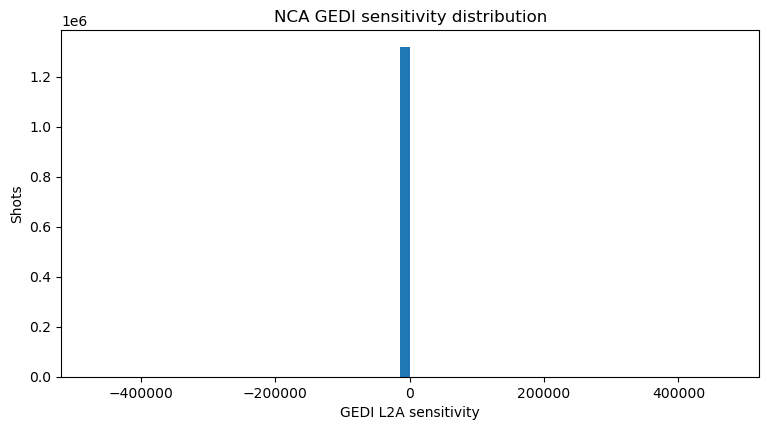

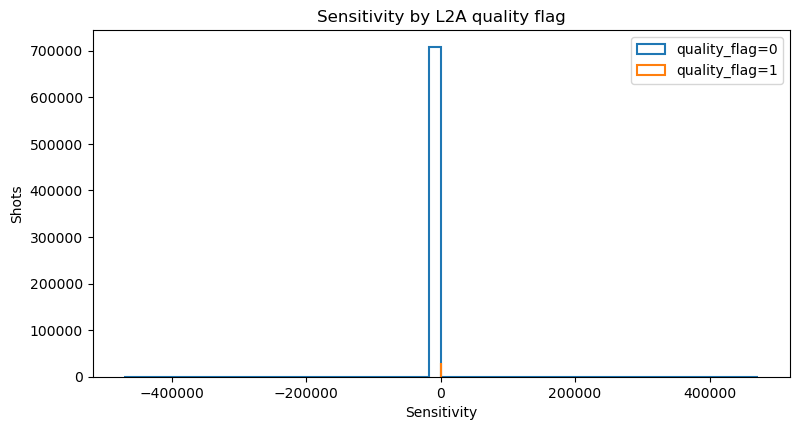

In [10]:
if "sensitivity" in paired_shots.columns:
    s = pd.to_numeric(paired_shots["sensitivity"], errors="coerce")
    display(s.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("sensitivity"))

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(s.dropna(), bins=60)
    ax.set_xlabel("GEDI L2A sensitivity")
    ax.set_ylabel("Shots")
    ax.set_title("NCA GEDI sensitivity distribution")
    plt.show()

    if "quality_flag" in paired_shots.columns:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        for flag, sub in paired_shots.groupby("quality_flag", dropna=False):
            vals = pd.to_numeric(sub["sensitivity"], errors="coerce").dropna()
            if len(vals):
                ax.hist(vals, bins=50, histtype="step", linewidth=1.5, label=f"quality_flag={flag}")
        ax.set_xlabel("Sensitivity")
        ax.set_ylabel("Shots")
        ax.set_title("Sensitivity by L2A quality flag")
        ax.legend()
        plt.show()


## 10. AOI coverage and beam representation

This is a coverage diagnostic, not a density-corrected ecological sample design.

We visualize:

- all retained L2A shot centers,
- the AOI boundary,
- spatial patterns of `quality_flag` where available.

Persistent spatial gaps or flag clusters are more consequential than a single archive-wide percentage.


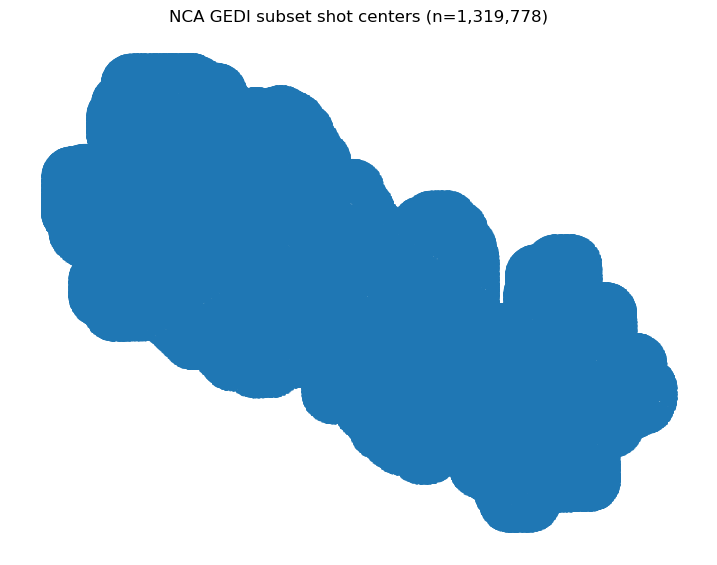

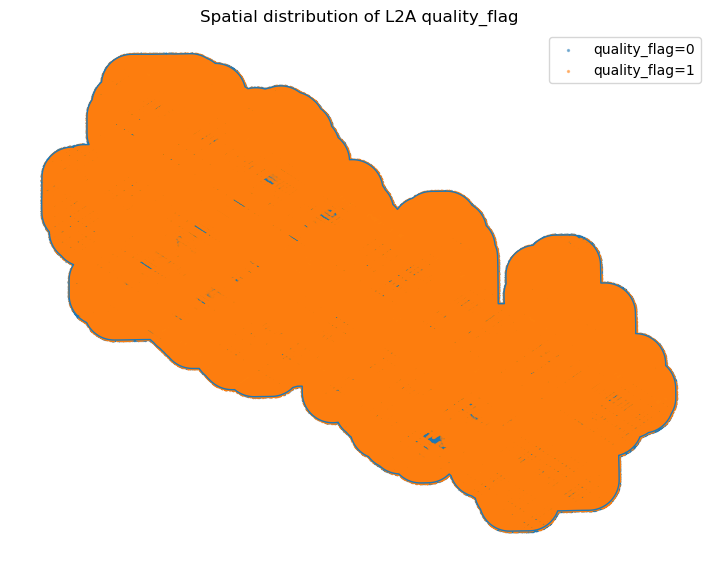

,shots
beam,
BEAM0110,166798
BEAM0011,166603
BEAM0101,166316
BEAM0010,166003
BEAM0001,164846
BEAM0000,164436
BEAM1011,162575
BEAM1000,162201


In [11]:
aoi = gpd.read_file(AOI_PATH)

if aoi.crs is None:
    raise ValueError("AOI has no CRS.")

if {"longitude_l2a", "latitude_l2a"}.issubset(paired_shots.columns):
    xy = paired_shots.dropna(subset=["longitude_l2a", "latitude_l2a"]).copy()

    shot_gdf = gpd.GeoDataFrame(
        xy,
        geometry=gpd.points_from_xy(xy["longitude_l2a"], xy["latitude_l2a"]),
        crs="EPSG:4326",
    ).to_crs(aoi.crs)

    fig, ax = plt.subplots(figsize=(9, 9))
    aoi.boundary.plot(ax=ax, linewidth=1)
    shot_gdf.plot(ax=ax, markersize=1, alpha=0.35)
    ax.set_title(f"NCA GEDI subset shot centers (n={len(shot_gdf):,})")
    ax.set_axis_off()
    plt.show()

    if "quality_flag" in shot_gdf.columns:
        fig, ax = plt.subplots(figsize=(9, 9))
        aoi.boundary.plot(ax=ax, linewidth=1)
        for flag, sub in shot_gdf.groupby("quality_flag", dropna=False):
            sub.plot(ax=ax, markersize=2, alpha=0.45, label=f"quality_flag={flag}")
        ax.set_title("Spatial distribution of L2A quality_flag")
        ax.set_axis_off()
        ax.legend()
        plt.show()

    beam_counts = (
        shot_gdf.groupby("beam")
        .size()
        .rename("shots")
        .sort_values(ascending=False)
        .to_frame()
    )
    display(beam_counts)
else:
    print("L2A longitude/latitude fields were not available.")


## 11. Horizontal L1B↔L2A coordinate consistency

For the same `shot_number`, compare:

- L1B `geolocation/latitude_bin0`, `longitude_bin0`
- L2A `lat_lowestmode`, `lon_lowestmode`

This is **not external geolocation accuracy** because the products are related.  
It is a useful internal consistency diagnostic and can expose gross mismatches, repacking errors, or unusual processing cases.

Distance is calculated with a haversine approximation.


,L1B-L2A horizontal offset (m)
count,1.319778e+06
mean,1.752945e+00
std,1.782913e+00
min,0.000000e+00
50%,1.218131e+00
90%,4.511636e+00
95%,4.874821e+00
99%,5.422095e+00
99.9%,1.069277e+01
max,2.069363e+01


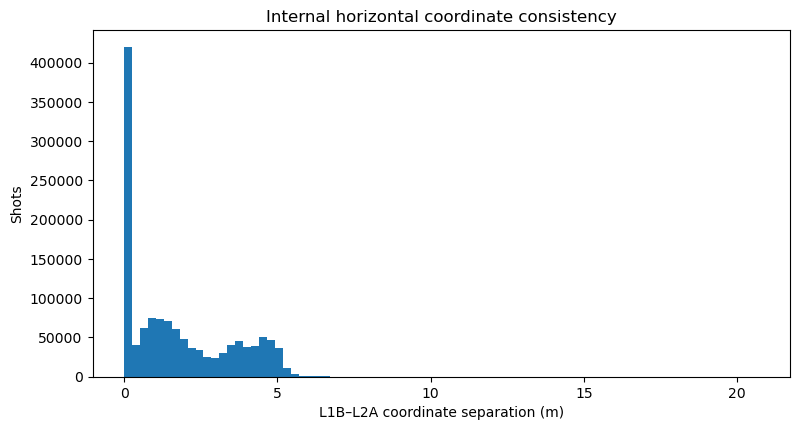


Largest coordinate disagreements:


,granule_key,beam,shot_number,l1b_l2a_horizontal_offset_m,quality_flag,degrade_flag,sensitivity
1159744,O30928_03_T08406_02,BEAM0001,309280100300130441,20.693628,0,0,0.741389
349810,O09038_03_T04443_02,BEAM0011,90380300300240137,17.576819,1,0,0.906287
348788,O09038_03_T04443_02,BEAM0010,90380200300245174,17.575925,1,0,0.936287
349836,O09038_03_T04443_02,BEAM0011,90380300300240163,17.401521,1,0,0.948515
616076,O16266_03_T11099_02,BEAM0000,162660000300135691,17.187630,0,0,0.833462
616275,O16266_03_T11099_02,BEAM0000,162660000300135917,17.160921,0,0,0.889064
616298,O16266_03_T11099_02,BEAM0000,162660000300135940,16.644076,0,0,0.853490
619466,O16266_03_T11099_02,BEAM0010,162660200300136601,16.539013,0,0,0.164054
336698,O08977_03_T01291_02,BEAM0011,89770300300130380,16.460763,0,0,0.633915
336617,O08977_03_T01291_02,BEAM0011,89770300300130299,16.438271,0,0,0.929598


In [12]:
EARTH_RADIUS_M = 6_371_008.8

def haversine_m(lon1, lat1, lon2, lat2):
    lon1 = np.radians(np.asarray(lon1, dtype=float))
    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lon2 = np.radians(np.asarray(lon2, dtype=float))
    lat2 = np.radians(np.asarray(lat2, dtype=float))

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * EARTH_RADIUS_M * np.arcsin(np.sqrt(a))

coord_cols = {
    "longitude_l1b", "latitude_l1b",
    "longitude_l2a", "latitude_l2a",
}

if coord_cols.issubset(paired_shots.columns):
    valid = paired_shots[list(coord_cols)].notna().all(axis=1)

    paired_shots.loc[valid, "l1b_l2a_horizontal_offset_m"] = haversine_m(
        paired_shots.loc[valid, "longitude_l1b"],
        paired_shots.loc[valid, "latitude_l1b"],
        paired_shots.loc[valid, "longitude_l2a"],
        paired_shots.loc[valid, "latitude_l2a"],
    )

    off = paired_shots["l1b_l2a_horizontal_offset_m"].dropna()

    display(
        off.describe(
            percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
        ).to_frame("L1B-L2A horizontal offset (m)")
    )

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(off, bins=80)
    ax.set_xlabel("L1B–L2A coordinate separation (m)")
    ax.set_ylabel("Shots")
    ax.set_title("Internal horizontal coordinate consistency")
    plt.show()

    print("\nLargest coordinate disagreements:")
    display(
        paired_shots.nlargest(
            20, "l1b_l2a_horizontal_offset_m"
        )[
            [
                "granule_key", "beam", "shot_number",
                "l1b_l2a_horizontal_offset_m",
                "quality_flag", "degrade_flag", "sensitivity"
            ]
        ]
    )
else:
    print("Required L1B/L2A coordinate fields are not all present.")


## 12. Elevation / DEM consistency

The most useful AOI-scale elevation residual is:

\[
r_{DEM} = z_{\mathrm{GEDI,\ lowestmode}} - z_{\mathrm{reference\ DEM}}
\]

This is not automatically an error term: GEDI's lowest detected return and the raster DEM do not represent precisely the same spatial/vertical support.

Use this to find structure, tails, flag associations, and implausible cases—not as an unquestioned rejection criterion.


,elev_lowestmode - DEM (m)
count,1.319778e+06
mean,3.174101e+03
std,3.288940e+04
min,-2.070201e+03
1%,-3.279772e+02
5%,-3.434171e+00
50%,6.014404e-01
95%,6.012844e+03
99%,8.298319e+03
max,4.575010e+05


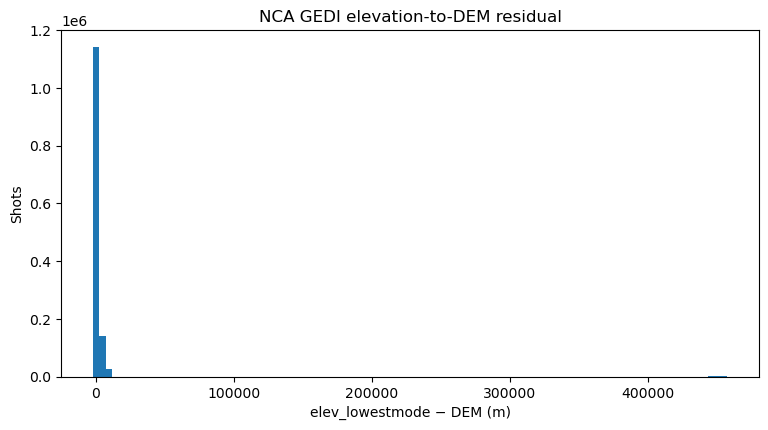

,count,median,mean,std
quality_flag,,,,
0,709008,42.913513,5908.065430,44695.954010
1,610770,0.145813,0.398713,9.575273


Largest absolute residuals:


,granule_key,beam,shot_number,elev_lowestmode,digital_elevation_model,lowestmode_minus_dem_m,surface_flag,quality_flag,degrade_flag,sensitivity
1284501,O33457_02_T09611_02,BEAM0011,334570300200195601,458527.84375,1026.825684,457501.03125,0,0,0,-0.114085
1284500,O33457_02_T09611_02,BEAM0011,334570300200195600,458522.34375,1026.916992,457495.43750,0,0,0,-1.906960
1284499,O33457_02_T09611_02,BEAM0011,334570300200195599,458517.00000,1027.984497,457489.00000,0,0,0,-2.505633
1284498,O33457_02_T09611_02,BEAM0011,334570300200195598,458511.53125,1027.055420,457484.46875,0,0,0,-1.797313
1284497,O33457_02_T09611_02,BEAM0011,334570300200195597,458506.18750,1027.055420,457479.12500,0,0,0,3.797951
1284496,O33457_02_T09611_02,BEAM0011,334570300200195596,458500.81250,1023.535400,457477.28125,0,0,0,-0.233034
1284495,O33457_02_T09611_02,BEAM0011,334570300200195595,458495.40625,1022.577454,457472.84375,0,0,0,1.965698
1284494,O33457_02_T09611_02,BEAM0011,334570300200195594,458490.00000,1022.724670,457467.28125,0,0,0,3.154108
1284493,O33457_02_T09611_02,BEAM0011,334570300200195593,458484.53125,1022.036438,457462.50000,0,0,0,1.596887
1283652,O33457_02_T09611_02,BEAM0010,334570200200199706,458477.68750,1020.348328,457457.34375,0,0,0,2.246779


In [13]:
if {"elev_lowestmode", "digital_elevation_model"}.issubset(paired_shots.columns):
    z = pd.to_numeric(paired_shots["elev_lowestmode"], errors="coerce")
    dem = pd.to_numeric(paired_shots["digital_elevation_model"], errors="coerce")

    paired_shots["lowestmode_minus_dem_m"] = z - dem
    resid = paired_shots["lowestmode_minus_dem_m"].replace([np.inf, -np.inf], np.nan).dropna()

    display(
        resid.describe(
            percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
        ).to_frame("elev_lowestmode - DEM (m)")
    )

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(resid, bins=100)
    ax.set_xlabel("elev_lowestmode − DEM (m)")
    ax.set_ylabel("Shots")
    ax.set_title("NCA GEDI elevation-to-DEM residual")
    plt.show()

    if "quality_flag" in paired_shots.columns:
        summary = (
            paired_shots.groupby("quality_flag")["lowestmode_minus_dem_m"]
            .agg(["count", "median", "mean", "std"])
        )
        display(summary)

    print("Largest absolute residuals:")
    tmp = paired_shots.assign(abs_dem_resid=paired_shots["lowestmode_minus_dem_m"].abs())
    display(
        tmp.nlargest(20, "abs_dem_resid")[
            [
                "granule_key", "beam", "shot_number",
                "elev_lowestmode", "digital_elevation_model",
                "lowestmode_minus_dem_m",
                "surface_flag", "quality_flag",
                "degrade_flag", "sensitivity"
            ]
        ]
    )
else:
    print("elev_lowestmode and/or digital_elevation_model unavailable.")


## 13. Relative-height structure

The repacked L2A files retain the native `rh` arrays.  
We extract a compact set of RH quantiles for exploratory AOI diagnostics.

For low-stature drylands, treat RH metrics cautiously: apparent vertical structure can reflect noise, ground-selection uncertainty, footprint heterogeneity, or true shrubs/trees.


RH: 25/189 files scanned
RH: 50/189 files scanned
RH: 75/189 files scanned
RH: 100/189 files scanned
RH: 125/189 files scanned
RH: 150/189 files scanned
RH: 175/189 files scanned
RH: 189/189 files scanned


,count,mean,std,min,25%,50%,75%,max
rh0,1319778.0,-2.841577,2.145467,-149.649994,-4.48,-3.55,0.00,0.000000
rh5,1319778.0,-1.944515,1.424601,-35.049999,-2.95,-2.58,0.00,13.740000
rh10,1319778.0,-1.523320,1.138274,-32.509998,-2.31,-2.02,0.00,25.240000
rh25,1319778.0,-0.794134,0.776330,-25.110001,-1.26,-1.08,0.00,75.669998
rh50,1319778.0,0.014293,1.167871,-14.380000,-0.18,-0.07,0.00,112.209999
rh75,1319778.0,0.808204,2.018189,-5.110000,0.00,0.78,0.92,130.630005
rh90,1319778.0,1.500124,2.666266,-0.330000,0.00,1.60,1.82,139.360001
rh95,1319778.0,1.885650,2.953500,0.000000,0.00,2.05,2.35,142.470001
rh98,1319778.0,2.273671,3.152689,0.000000,0.00,2.54,2.88,144.110001
rh100,1319778.0,2.904172,3.422898,0.000000,0.00,3.40,3.84,145.460007


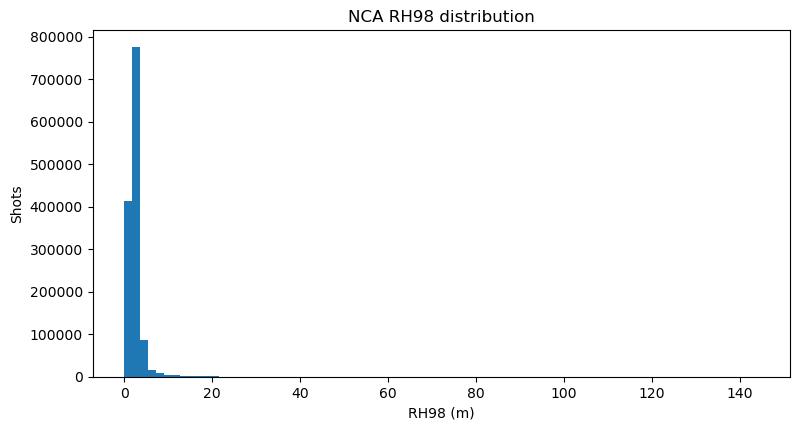

In [14]:
RH_INDICES = [0, 5, 10, 25, 50, 75, 90, 95, 98, 100]

def extract_rh_table(path):
    parts = []

    with h5py.File(path, "r") as h5:
        for beam in list_beams(h5):
            g = h5[beam]

            if "shot_number" not in g or "rh" not in g:
                continue

            shot = np.asarray(g["shot_number"])
            rh = np.asarray(g["rh"])

            if rh.ndim != 2 or rh.shape[0] != len(shot):
                continue

            out = {
                "granule_key": np.repeat(orbit_key(path), len(shot)),
                "beam": np.repeat(beam, len(shot)),
                "shot_number": shot.astype(np.uint64),
            }

            for idx in RH_INDICES:
                if idx < rh.shape[1]:
                    out[f"rh{idx}"] = rh[:, idx]

            parts.append(pd.DataFrame(out))

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

rh_parts = []
for i, p in enumerate(l2a_files, 1):
    df = extract_rh_table(p)
    if not df.empty:
        rh_parts.append(df)
    if i % 25 == 0 or i == len(l2a_files):
        print(f"RH: {i:,}/{len(l2a_files):,} files scanned")

rh_table = pd.concat(rh_parts, ignore_index=True) if rh_parts else pd.DataFrame()

if not rh_table.empty:
    paired_shots = paired_shots.merge(
        rh_table,
        on=["granule_key", "beam", "shot_number"],
        how="left",
        validate="one_to_one",
    )

    rh_cols = [c for c in paired_shots.columns if re.fullmatch(r"rh\d+", c)]
    display(paired_shots[rh_cols].describe().T)

    if "rh98" in paired_shots.columns:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        vals = pd.to_numeric(paired_shots["rh98"], errors="coerce").dropna()
        ax.hist(vals, bins=80)
        ax.set_xlabel("RH98 (m)")
        ax.set_ylabel("Shots")
        ax.set_title("NCA RH98 distribution")
        plt.show()
else:
    print("No RH arrays found.")


## 14. Full-waveform extraction

L1B stores receive/transmit waveforms as concatenated vectors.  
Each shot is recovered from its 1-based start index and sample count.

The repacker rebuilt those vectors and indices for the retained AOI shots, so this cell also functions as an independent spot-check of the repacked archive.


In [15]:
def get_waveform_segment(group, prefix, shot_index):
    wf_name = f"{prefix}waveform"
    start_name = f"{prefix}_sample_start_index"
    count_name = f"{prefix}_sample_count"

    if not all(name in group for name in [wf_name, start_name, count_name]):
        return None

    start = int(group[start_name][shot_index])
    count = int(group[count_name][shot_index])

    # GEDI waveform start indices are 1-based.
    i0 = start - 1
    i1 = i0 + count

    if i0 < 0 or i1 > len(group[wf_name]):
        raise IndexError(
            f"Waveform bounds invalid in {group.name}: "
            f"{prefix} start={start}, count={count}, waveform_len={len(group[wf_name])}"
        )

    return np.asarray(group[wf_name][i0:i1])

def load_l1b_waveforms(l1b_path, beam, shot_number):
    with h5py.File(l1b_path, "r") as h5:
        if beam not in h5:
            raise KeyError(f"{beam} not found in {l1b_path.name}")

        g = h5[beam]
        shots = np.asarray(g["shot_number"])
        idx = np.flatnonzero(shots == np.uint64(shot_number))

        if len(idx) != 1:
            raise KeyError(
                f"Expected exactly one match for shot {shot_number} in "
                f"{l1b_path.name} {beam}; found {len(idx)}"
            )

        i = int(idx[0])
        rx = get_waveform_segment(g, "rx", i)
        tx = get_waveform_segment(g, "tx", i)

    return rx, tx

def l1b_path_for_key(key):
    p = l1b_lookup.get(key)
    if p is None:
        raise KeyError(f"No L1B subset for {key}")
    return p


## 15. Plot a single shot in detail

Use this cell interactively by changing `ROW_INDEX`, or leave it at zero for the first paired shot.

The x-axis is waveform sample number rather than physical elevation.  
We can add sample-to-elevation conversion later if we want waveform returns registered vertically against `elev_lowestmode` and `elev_highestreturn`.


granule_key                O02061_02_T00905_02
beam                                  BEAM0000
shot_number                  20610000200092326
quality_flag                                 0
degrade_flag                                 0
sensitivity                           0.899808
surface_flag                                 1
selected_algorithm                           1
num_detectedmodes                            1
elev_lowestmode                     768.667969
digital_elevation_model             769.313293
rh98                                      2.65
rh100                                      3.4
Name: 0, dtype: object


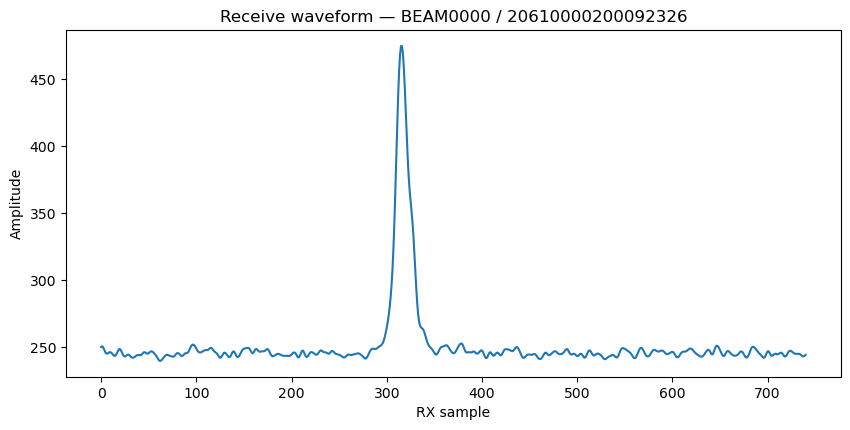

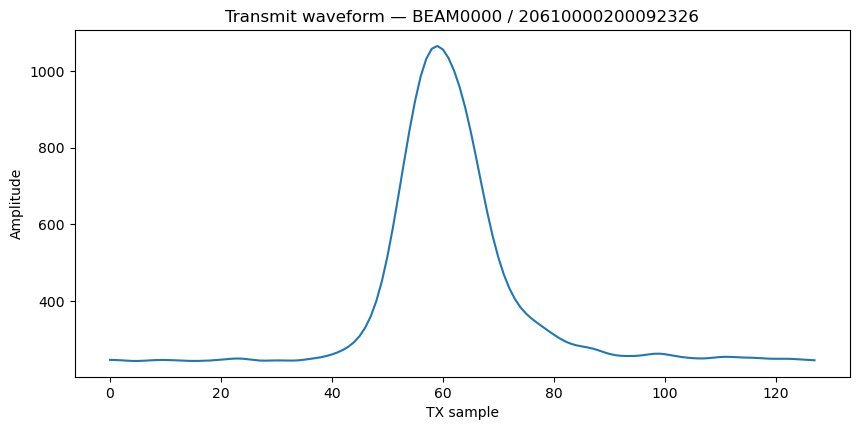

In [16]:
ROW_INDEX = 0

row = paired_shots.iloc[ROW_INDEX]

rx, tx = load_l1b_waveforms(
    l1b_path_for_key(row["granule_key"]),
    row["beam"],
    row["shot_number"],
)

print(row[
    [c for c in [
        "granule_key", "beam", "shot_number",
        "quality_flag", "degrade_flag", "sensitivity",
        "surface_flag", "selected_algorithm", "num_detectedmodes",
        "elev_lowestmode", "digital_elevation_model",
        "rh98", "rh100"
    ] if c in row.index]
])

if rx is not None:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(np.arange(len(rx)), rx)
    ax.set_xlabel("RX sample")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Receive waveform — {row['beam']} / {int(row['shot_number'])}")
    plt.show()

if tx is not None:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(np.arange(len(tx)), tx)
    ax.set_xlabel("TX sample")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Transmit waveform — {row['beam']} / {int(row['shot_number'])}")
    plt.show()


## 16. Select representative waveform classes

The purpose is to compare morphology, not to define a final filter.

Classes are generated only when the necessary fields exist:

- `standard_good`: `quality_flag == 1`, no obvious degradation, high sensitivity
- `quality_bad`: `quality_flag == 0`
- `degraded`: non-zero / uncommon degradation code
- `low_sensitivity`: lower tail of the AOI sensitivity distribution
- `many_modes`: upper tail of detected-mode count
- `large_dem_residual`: large absolute lowest-mode minus DEM residual

The categories may overlap. That is scientifically useful because it reveals whether different diagnostics identify the same shots.


In [17]:
rng = np.random.default_rng(RANDOM_SEED)

def sample_rows(df, mask, n=N_WAVEFORMS_PER_CLASS):
    idx = np.flatnonzero(np.asarray(mask.fillna(False) if hasattr(mask, "fillna") else mask))
    if len(idx) == 0:
        return df.iloc[0:0].copy()
    choose = rng.choice(idx, size=min(n, len(idx)), replace=False)
    return df.iloc[choose].copy()

classes = {}

if {"quality_flag", "sensitivity"}.issubset(paired_shots.columns):
    deg_ok = (
        paired_shots["degrade_flag"].eq(0)
        if "degrade_flag" in paired_shots.columns
        else pd.Series(True, index=paired_shots.index)
    )

    classes["standard_good"] = sample_rows(
        paired_shots,
        paired_shots["quality_flag"].eq(1)
        & deg_ok
        & pd.to_numeric(paired_shots["sensitivity"], errors="coerce").ge(0.9)
    )

    classes["quality_bad"] = sample_rows(
        paired_shots,
        paired_shots["quality_flag"].eq(0)
    )

if "degrade_flag" in paired_shots.columns:
    classes["degraded"] = sample_rows(
        paired_shots,
        paired_shots["degrade_flag"].ne(0)
    )

if "sensitivity" in paired_shots.columns:
    s = pd.to_numeric(paired_shots["sensitivity"], errors="coerce")
    q10 = s.quantile(0.10)
    classes["low_sensitivity"] = sample_rows(
        paired_shots,
        s.le(q10)
    )

if "num_detectedmodes" in paired_shots.columns:
    modes = pd.to_numeric(paired_shots["num_detectedmodes"], errors="coerce")
    q90 = modes.quantile(0.90)
    classes["many_modes"] = sample_rows(
        paired_shots,
        modes.ge(q90)
    )

if "lowestmode_minus_dem_m" in paired_shots.columns:
    abs_r = paired_shots["lowestmode_minus_dem_m"].abs()
    q99 = abs_r.quantile(0.99)
    classes["large_dem_residual"] = sample_rows(
        paired_shots,
        abs_r.ge(q99)
    )

class_summary = pd.concat(
    [
        df.assign(diagnostic_class=name)
        for name, df in classes.items()
        if not df.empty
    ],
    ignore_index=True,
) if any(not df.empty for df in classes.values()) else pd.DataFrame()

display(
    class_summary[
        [c for c in [
            "diagnostic_class", "granule_key", "beam", "shot_number",
            "quality_flag", "degrade_flag", "sensitivity",
            "surface_flag", "selected_algorithm", "num_detectedmodes",
            "elev_lowestmode", "digital_elevation_model",
            "lowestmode_minus_dem_m", "rh98"
        ] if c in class_summary.columns]
    ]
)


,diagnostic_class,granule_key,beam,shot_number,quality_flag,degrade_flag,sensitivity,surface_flag,selected_algorithm,num_detectedmodes,elev_lowestmode,digital_elevation_model,lowestmode_minus_dem_m,rh98
0,standard_good,O16083_03_T07289_02,BEAM0010,160830200300133128,1,0,0.921283,1,1,1,861.341797,862.425781,-1.083984,3.390000
1,standard_good,O02752_03_T01597_02,BEAM0000,27520000300132810,1,0,0.929733,1,1,1,917.101013,916.510376,0.590637,2.880000
2,standard_good,O20522_03_T11099_02,BEAM0010,205220200300135169,1,0,0.909852,1,1,1,782.183655,779.807129,2.376526,3.660000
3,standard_good,O22353_03_T08559_02,BEAM0101,223530500300128408,1,0,0.959882,1,1,1,954.194702,954.410400,-0.215698,2.500000
4,quality_bad,O20488_02_T06597_02,BEAM0010,204880200200110972,0,70,0.885040,1,1,1,1022.560364,1022.880127,-0.319763,2.690000
5,quality_bad,O08760_02_T02634_02,BEAM0110,87600600200333401,0,0,0.940923,0,1,2,3244.906738,742.467102,2502.439697,8.400000
6,quality_bad,O04611_02_T04409_02,BEAM0010,46110200200091684,0,70,0.893330,1,1,1,709.481018,708.605774,0.875244,2.840000
7,quality_bad,O17608_03_T08253_02,BEAM1000,176080800300246681,0,0,0.791860,0,1,0,3196.999023,777.557190,2419.441895,0.000000
8,degraded,O18981_03_T07136_02,BEAM0010,189810200300245615,0,80,-55.262619,1,1,0,956.613953,943.355835,13.258118,0.000000
9,degraded,O14128_02_T09137_02,BEAM0110,141280600200388141,0,80,0.073525,0,1,0,3305.820068,912.395874,2393.424316,0.000000


## 17. Plot representative receive waveforms by diagnostic class


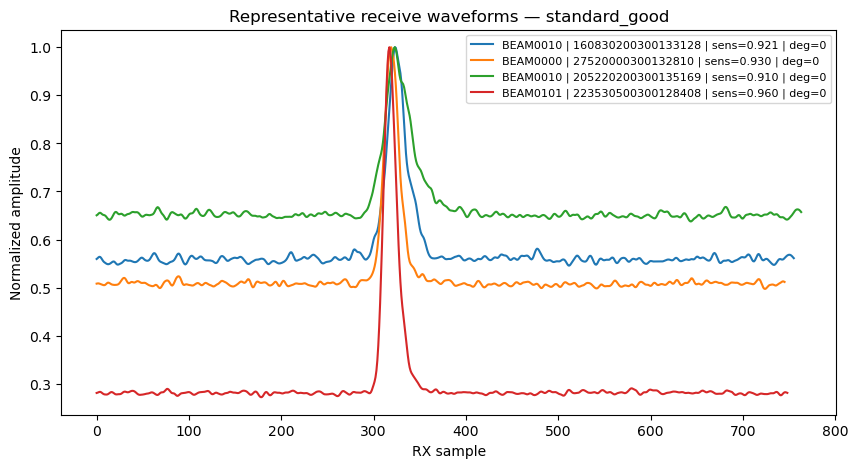

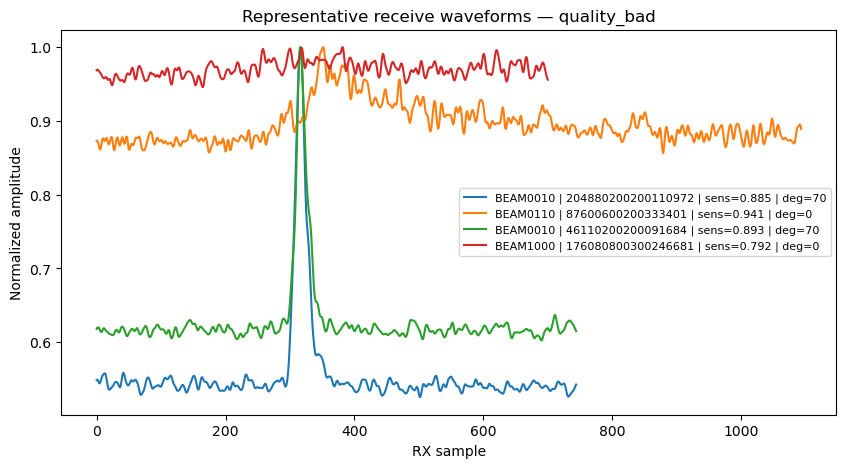

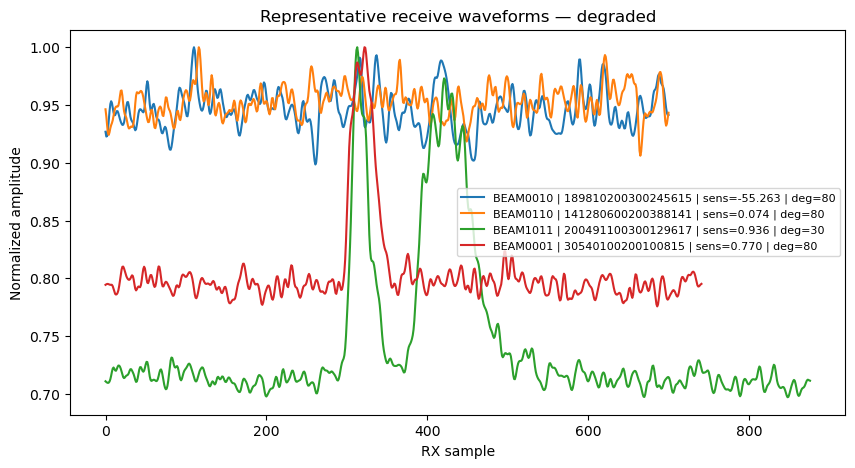

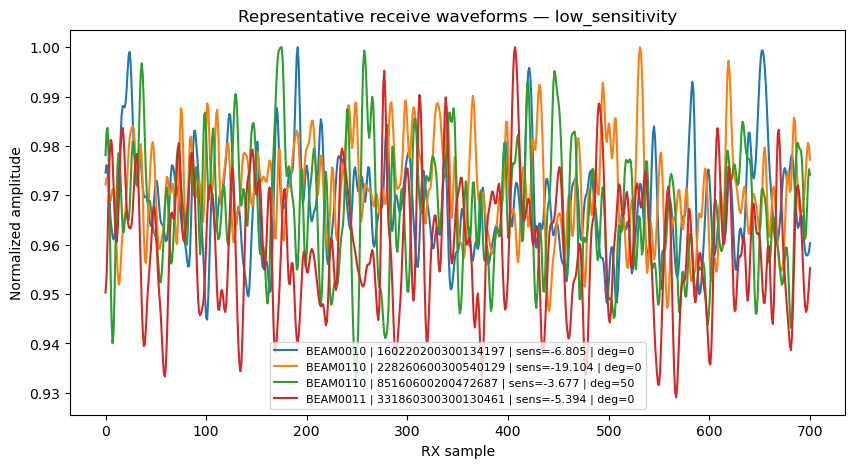

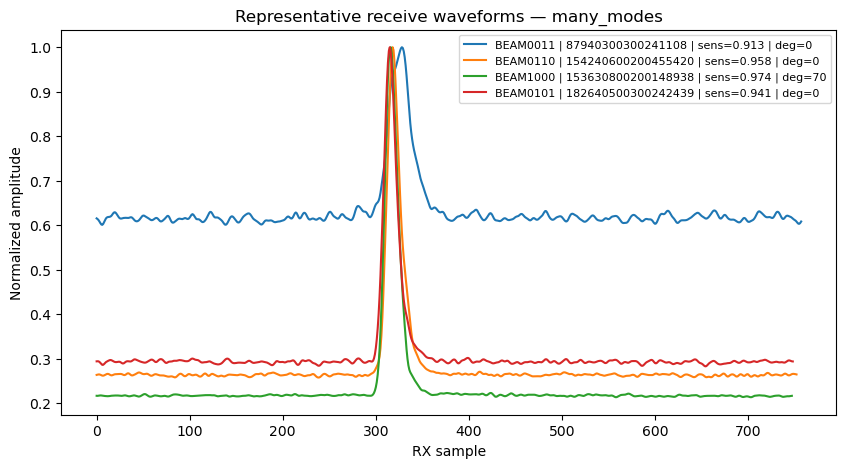

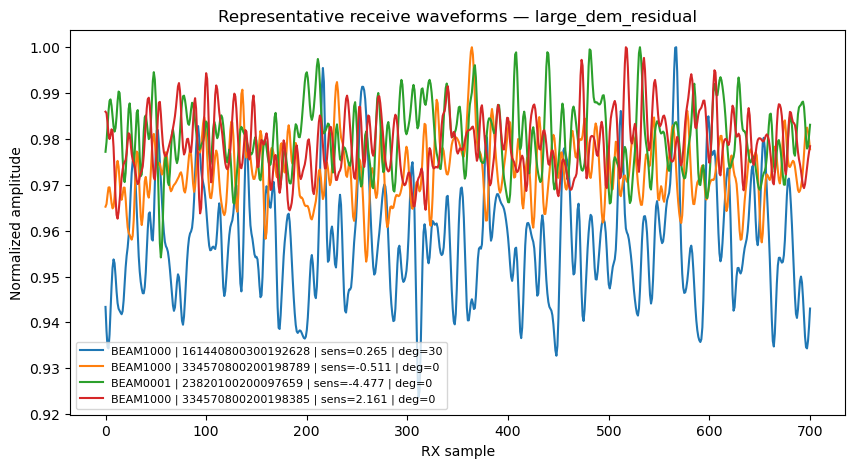

In [18]:
def plot_waveform_class(df, class_name):
    if df.empty:
        print(f"{class_name}: no qualifying shots")
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    plotted = 0
    for _, row in df.iterrows():
        try:
            rx, _ = load_l1b_waveforms(
                l1b_path_for_key(row["granule_key"]),
                row["beam"],
                row["shot_number"],
            )
        except Exception as exc:
            print("Waveform read failed:", exc)
            continue

        if rx is None or len(rx) == 0:
            continue

        # Normalize only for shape comparison in this multi-shot overlay.
        # Raw-amplitude plots remain available in the single-shot cell.
        rx = np.asarray(rx, dtype=float)
        denom = np.nanmax(np.abs(rx))
        rxn = rx / denom if np.isfinite(denom) and denom > 0 else rx

        label_bits = [
            str(row["beam"]),
            str(int(row["shot_number"])),
        ]
        if "sensitivity" in row.index and pd.notna(row["sensitivity"]):
            label_bits.append(f"sens={row['sensitivity']:.3f}")
        if "degrade_flag" in row.index and pd.notna(row["degrade_flag"]):
            label_bits.append(f"deg={row['degrade_flag']}")

        ax.plot(np.arange(len(rxn)), rxn, label=" | ".join(label_bits))
        plotted += 1

    ax.set_xlabel("RX sample")
    ax.set_ylabel("Normalized amplitude")
    ax.set_title(f"Representative receive waveforms — {class_name}")
    if plotted:
        ax.legend(fontsize=8)
    plt.show()

for name, df in classes.items():
    plot_waveform_class(df, name)


## 18. Flag combinations and retention scenarios

This cell quantifies several candidate filtering rules **without modifying the data**.

The standard V2-style criterion `quality_flag == 1` plus high sensitivity is shown alongside stricter and looser alternatives.  
These are scenarios for comparison, not recommendations.

Note that some later GEDI products accept several low-order `degrade_flag` codes as not significantly degraded rather than requiring exactly zero; the AOI-specific distributions above should inform whether such distinctions matter here.


In [19]:
scenario = pd.DataFrame(index=paired_shots.index)

if "quality_flag" in paired_shots:
    scenario["quality_1"] = paired_shots["quality_flag"].eq(1)

if "degrade_flag" in paired_shots:
    scenario["degrade_0"] = paired_shots["degrade_flag"].eq(0)
    scenario["degrade_l4d_allowed"] = paired_shots["degrade_flag"].isin(
        [0, 3, 10, 13, 20, 23, 30, 33]
    )

if "sensitivity" in paired_shots:
    sens = pd.to_numeric(paired_shots["sensitivity"], errors="coerce")
    scenario["sensitivity_ge_0_90"] = sens.ge(0.90)
    scenario["sensitivity_ge_0_95"] = sens.ge(0.95)

candidate_masks = {}

if {"quality_1", "degrade_0", "sensitivity_ge_0_90"}.issubset(scenario.columns):
    candidate_masks["strict_q1_deg0_sens90"] = (
        scenario["quality_1"]
        & scenario["degrade_0"]
        & scenario["sensitivity_ge_0_90"]
    )

if {"quality_1", "degrade_l4d_allowed", "sensitivity_ge_0_90"}.issubset(scenario.columns):
    candidate_masks["q1_alloweddeg_sens90"] = (
        scenario["quality_1"]
        & scenario["degrade_l4d_allowed"]
        & scenario["sensitivity_ge_0_90"]
    )

if {"quality_1", "sensitivity_ge_0_90"}.issubset(scenario.columns):
    candidate_masks["q1_sens90"] = (
        scenario["quality_1"]
        & scenario["sensitivity_ge_0_90"]
    )

if "quality_1" in scenario.columns:
    candidate_masks["quality_only"] = scenario["quality_1"]

rows = []
for name, mask in candidate_masks.items():
    rows.append({
        "scenario": name,
        "retained": int(mask.sum()),
        "total": len(mask),
        "retained_percent": 100 * mask.mean(),
    })

scenario_summary = pd.DataFrame(rows).sort_values("retained_percent", ascending=False)
display(scenario_summary)


,scenario,retained,total,retained_percent
3,quality_only,610770,1319778,46.278238
2,q1_sens90,610770,1319778,46.278238
1,q1_alloweddeg_sens90,477023,1319778,36.144185
0,strict_q1_deg0_sens90,449017,1319778,34.022161


## 19. Diagnose whether filtering changes the AOI sample

A quality filter can create a biased ecological sample even when it improves measurement reliability.

For each candidate scenario we therefore compare, where available:

- beam composition,
- solar elevation,
- DEM elevation,
- sensitivity,
- RH98,
- spatial footprint coverage.

A filter that disproportionately removes particular beams, terrain, or parts of the AOI deserves scrutiny before use in ecological inference.


In [20]:
diagnostic_vars = [
    c for c in [
        "solar_elevation",
        "digital_elevation_model",
        "sensitivity",
        "rh98",
        "lowestmode_minus_dem_m",
        "l1b_l2a_horizontal_offset_m",
    ]
    if c in paired_shots.columns
]

summary_rows = []

for name, mask in {"all_spatial": pd.Series(True, index=paired_shots.index), **candidate_masks}.items():
    sub = paired_shots.loc[mask]

    row = {
        "scenario": name,
        "n": len(sub),
        "percent_of_spatial": 100 * len(sub) / len(paired_shots) if len(paired_shots) else np.nan,
        "n_beams": sub["beam"].nunique(),
        "n_granules": sub["granule_key"].nunique(),
    }

    for col in diagnostic_vars:
        vals = pd.to_numeric(sub[col], errors="coerce")
        row[f"{col}_median"] = vals.median()
        row[f"{col}_p05"] = vals.quantile(0.05)
        row[f"{col}_p95"] = vals.quantile(0.95)

    summary_rows.append(row)

filter_diagnostic_summary = pd.DataFrame(summary_rows)
display(filter_diagnostic_summary)


,scenario,n,percent_of_spatial,n_beams,n_granules,solar_elevation_median,solar_elevation_p05,solar_elevation_p95,digital_elevation_model_median,digital_elevation_model_p05,digital_elevation_model_p95,sensitivity_median,sensitivity_p05,sensitivity_p95,rh98_median,rh98_p05,rh98_p95,lowestmode_minus_dem_m_median,lowestmode_minus_dem_m_p05,lowestmode_minus_dem_m_p95,l1b_l2a_horizontal_offset_m_median,l1b_l2a_horizontal_offset_m_p05,l1b_l2a_horizontal_offset_m_p95
0,all_spatial,1319778,100.000000,8,189,8.204765,-57.182439,57.955027,895.493958,732.419214,1008.893707,0.922962,-1.402202,3.279944,2.54,0.00,4.47,0.601440,-3.434171,6012.844482,1.218131,0.000000,4.874821
1,strict_q1_deg0_sens90,449017,34.022161,8,124,-1.181037,-57.326434,42.269303,901.501038,739.107898,1010.681274,0.952415,0.905848,0.974611,2.69,2.36,4.70,0.179321,-2.042908,2.398950,1.909784,0.528660,5.054150
2,q1_alloweddeg_sens90,477023,36.144185,8,130,-0.876306,-57.285488,50.705367,899.562744,738.454651,1009.342853,0.952330,0.905787,0.974435,2.69,2.36,4.75,0.170044,-2.132501,2.444147,1.937216,0.504583,5.056240
3,q1_sens90,610770,46.278238,8,157,6.826952,-56.898481,56.363290,898.655334,734.880676,1008.356891,0.952331,0.905891,0.973921,2.69,2.36,4.75,0.145813,-2.489297,2.857034,1.978266,0.440593,5.028664
4,quality_only,610770,46.278238,8,157,6.826952,-56.898481,56.363290,898.655334,734.880676,1008.356891,0.952331,0.905891,0.973921,2.69,2.36,4.75,0.145813,-2.489297,2.857034,1.978266,0.440593,5.028664


## 20. Inspect extreme / contradictory cases

These are especially informative:

- `quality_flag == 1` but large DEM residual,
- `quality_flag == 0` but apparently clean waveform / high sensitivity,
- `surface_flag == 1` but large within-AOI residual relative to most shots,
- low sensitivity with simple single-mode waveforms,
- many detected modes in otherwise low-stature areas.

They test whether a generic filtering recipe maps cleanly onto the ecological/measurement problem in the NCA.


In [21]:
columns_to_show = [
    c for c in [
        "granule_key", "beam", "shot_number",
        "quality_flag", "degrade_flag", "sensitivity", "surface_flag",
        "selected_algorithm", "selected_mode_flag", "num_detectedmodes",
        "elev_lowestmode", "digital_elevation_model",
        "lowestmode_minus_dem_m",
        "l1b_l2a_horizontal_offset_m",
        "rh50", "rh90", "rh98", "rh100",
    ]
    if c in paired_shots.columns
]

if {"quality_flag", "lowestmode_minus_dem_m"}.issubset(paired_shots.columns):
    threshold = paired_shots["lowestmode_minus_dem_m"].abs().quantile(0.99)
    print("quality_flag == 1 with top-1% absolute DEM residual:")
    display(
        paired_shots.loc[
            paired_shots["quality_flag"].eq(1)
            & paired_shots["lowestmode_minus_dem_m"].abs().ge(threshold),
            columns_to_show,
        ].head(30)
    )

if {"quality_flag", "sensitivity"}.issubset(paired_shots.columns):
    print("\nquality_flag == 0 but sensitivity >= 0.95:")
    display(
        paired_shots.loc[
            paired_shots["quality_flag"].eq(0)
            & pd.to_numeric(paired_shots["sensitivity"], errors="coerce").ge(0.95),
            columns_to_show,
        ].head(30)
    )


quality_flag == 1 with top-1% absolute DEM residual:


,granule_key,beam,shot_number,quality_flag,degrade_flag,sensitivity,surface_flag,selected_algorithm,selected_mode_flag,num_detectedmodes,elev_lowestmode,digital_elevation_model,lowestmode_minus_dem_m,l1b_l2a_horizontal_offset_m,rh50,rh90,rh98,rh100



quality_flag == 0 but sensitivity >= 0.95:


,granule_key,beam,shot_number,quality_flag,degrade_flag,sensitivity,surface_flag,selected_algorithm,selected_mode_flag,num_detectedmodes,elev_lowestmode,digital_elevation_model,lowestmode_minus_dem_m,l1b_l2a_horizontal_offset_m,rh50,rh90,rh98,rh100
126,O02061_02_T00905_02,BEAM0000,20610000200092452,0,0,0.994771,1,1,0,1,731.764954,751.846619,-20.081665,0.918440,-0.14,1.76,2.84,4.94
350,O02061_02_T00905_02,BEAM0000,20610000200092676,0,0,2.933792,1,1,0,0,1051.365723,901.121521,150.244202,0.000000,0.00,0.00,0.00,0.00
351,O02061_02_T00905_02,BEAM0000,20610000200092677,0,0,3.286444,1,1,0,0,945.601196,900.412720,45.188477,0.000000,0.00,0.00,0.00,0.00
352,O02061_02_T00905_02,BEAM0000,20610000200092678,0,0,3.848663,1,1,0,0,945.693298,900.412720,45.280579,0.000000,0.00,0.00,0.00,0.00
353,O02061_02_T00905_02,BEAM0000,20610000200092679,0,0,2.687605,1,1,0,0,944.878784,900.169434,44.709351,0.000000,0.00,0.00,0.00,0.00
355,O02061_02_T00905_02,BEAM0000,20610000200092681,0,0,4.057035,1,1,0,0,945.236023,900.410828,44.825195,0.000000,0.00,0.00,0.00,0.00
356,O02061_02_T00905_02,BEAM0000,20610000200092682,0,0,1.895247,1,1,0,0,946.874084,900.408447,46.465637,0.000000,0.00,0.00,0.00,0.00
357,O02061_02_T00905_02,BEAM0000,20610000200092683,0,0,7.679322,1,1,0,0,947.583496,900.823181,46.760315,0.000000,0.00,0.00,0.00,0.00
358,O02061_02_T00905_02,BEAM0000,20610000200092684,0,0,2.655570,1,1,0,0,947.223083,900.998169,46.224915,0.000000,0.00,0.00,0.00,0.00
395,O02061_02_T00905_02,BEAM0000,20610000200092721,0,0,2.921625,1,1,0,0,955.930298,910.409851,45.520447,0.000000,0.00,0.00,0.00,0.00


## 21. Save compact diagnostic tables (optional)

This does **not** rewrite or filter the HDF5 archive.

Uncomment the exports if we want persistent AOI-level diagnostic tables after inspecting the notebook results.


In [22]:
DIAGNOSTIC_OUT = SUBSET_ROOT / "diagnostics"

# DIAGNOSTIC_OUT.mkdir(parents=True, exist_ok=True)
#
# paired_shots.to_parquet(
#     DIAGNOSTIC_OUT / "NCA_GEDI_L1B_L2A_paired_shot_diagnostics.parquet",
#     index=False,
# )
#
# scenario_summary.to_csv(
#     DIAGNOSTIC_OUT / "NCA_GEDI_quality_filter_scenarios.csv",
#     index=False,
# )
#
# filter_diagnostic_summary.to_csv(
#     DIAGNOSTIC_OUT / "NCA_GEDI_filter_distribution_diagnostics.csv",
#     index=False,
# )
#
# print("Would write diagnostics to:", DIAGNOSTIC_OUT)


## 22. Interpretation checklist

After running the notebook, the next filter decision should answer:

1. **How many spatially valid NCA shots fail `quality_flag` and why?**
2. **Which `degrade_flag` codes actually occur, and are they associated with measurable coordinate/elevation problems?**
3. **Does sensitivity have a clear breakpoint in waveform quality or derived heights?**
4. **Do candidate filters remove shots non-randomly in space, beam, terrain, or solar geometry?**
5. **Are the extreme RH values supported by plausible full waveforms?**
6. **Do large DEM residuals correspond to obvious waveform/ground-selection failures, or simply terrain/support differences?**
7. **Does one filtering rule improve measurement reliability enough to justify the ecological sample it removes?**

The final science filter should be chosen from these observed tradeoffs rather than imported wholesale from a forest-oriented GEDI workflow.


## Proposed retained GEDI science subset

For the primary science subset, retain shots meeting:

- `quality_flag == 1`
- `degrade_flag ∈ {0, 3, 10, 13, 20, 23, 30, 33}`
- finite sensitivity in the physical range `[0, 1]`
- `sensitivity >= 0.90`

In the NCA data inspected so far, the accepted degradation set appears to reduce effectively to **0 and 30** because the other accepted codes are absent.

This cell does not modify the HDF5 archive. It creates an in-memory `gedi_keep` table and evaluates what the retained population looks like.

In [23]:
# =============================================================================
# Proposed primary GEDI science-quality subset
# =============================================================================

ACCEPTED_DEGRADE_FLAGS = {0, 3, 10, 13, 20, 23, 30, 33}
MIN_SENSITIVITY = 0.90

required = {"quality_flag", "degrade_flag", "sensitivity"}
missing = required - set(paired_shots.columns)

if missing:
    raise KeyError(
        f"Required filtering fields missing: {sorted(missing)}"
    )

sens = pd.to_numeric(
    paired_shots["sensitivity"],
    errors="coerce",
)

valid_sensitivity = (
    sens.notna()
    & np.isfinite(sens)
    & sens.between(0.0, 1.0, inclusive="both")
)

keep_mask = (
    paired_shots["quality_flag"].eq(1)
    & paired_shots["degrade_flag"].isin(ACCEPTED_DEGRADE_FLAGS)
    & valid_sensitivity
    & sens.ge(MIN_SENSITIVITY)
)

gedi_keep = paired_shots.loc[keep_mask].copy()

print("PROPOSED GEDI SCIENCE SUBSET")
print("----------------------------")
print(f"Spatial subset shots: {len(paired_shots):,}")
print(f"Retained shots:       {len(gedi_keep):,}")
print(
    f"Retention:            "
    f"{100 * len(gedi_keep) / len(paired_shots):.2f}%"
)

print(
    "\nAccepted degrade flags actually present:",
    sorted(
        set(
            gedi_keep["degrade_flag"]
            .dropna()
            .astype(int)
        )
    )
)

# -------------------------------------------------------------------------
# Sequential attrition
# -------------------------------------------------------------------------

stage_masks = {
    "all spatial shots":
        pd.Series(True, index=paired_shots.index),

    "valid sensitivity [0,1]":
        valid_sensitivity,

    "quality_flag == 1":
        valid_sensitivity
        & paired_shots["quality_flag"].eq(1),

    "quality + accepted degrade":
        valid_sensitivity
        & paired_shots["quality_flag"].eq(1)
        & paired_shots["degrade_flag"].isin(
            ACCEPTED_DEGRADE_FLAGS
        ),

    "final: + sensitivity >= 0.90":
        keep_mask,
}

attrition_rows = []

for stage, mask in stage_masks.items():

    n = int(mask.sum())

    attrition_rows.append(
        {
            "stage": stage,
            "n": n,
            "percent_of_spatial":
                100 * n / len(paired_shots),
        }
    )

attrition = pd.DataFrame(attrition_rows)

display(attrition)

# -------------------------------------------------------------------------
# Retained flag combinations
# -------------------------------------------------------------------------

print("\nRetained quality/degrade combinations:")

display(
    gedi_keep
    .groupby(
        ["quality_flag", "degrade_flag"]
    )
    .size()
    .rename("n")
    .reset_index()
    .assign(
        percent=lambda d:
            100 * d["n"] / d["n"].sum()
    )
)

# -------------------------------------------------------------------------
# Beam-specific retention
# -------------------------------------------------------------------------

beam_before = (
    paired_shots
    .groupby("beam")
    .size()
    .rename("n_spatial")
    .to_frame()
)

beam_after = (
    gedi_keep
    .groupby("beam")
    .size()
    .rename("n_keep")
    .to_frame()
)

beam_compare = (
    beam_before
    .join(
        beam_after,
        how="left",
    )
    .fillna(0)
)

beam_compare["retained_percent"] = (
    100
    * beam_compare["n_keep"]
    / beam_compare["n_spatial"]
)

display(beam_compare)

PROPOSED GEDI SCIENCE SUBSET
----------------------------
Spatial subset shots: 1,319,778
Retained shots:       477,023
Retention:            36.14%

Accepted degrade flags actually present: [0, 30]


,stage,n,percent_of_spatial
0,all spatial shots,1319778,100.000000
1,"valid sensitivity [0,1]",1035958,78.494868
2,quality_flag == 1,610770,46.278238
3,quality + accepted degrade,477023,36.144185
4,final: + sensitivity >= 0.90,477023,36.144185



Retained quality/degrade combinations:


,quality_flag,degrade_flag,n,percent
0,1,0,449017,94.129004
1,1,30,28006,5.870996


,n_spatial,n_keep,retained_percent
beam,,,
BEAM0000,164436,29380,17.867134
BEAM0001,164846,32104,19.475147
BEAM0010,166003,43013,25.910978
BEAM0011,166603,50707,30.435826
BEAM0101,166316,80463,48.379591
BEAM0110,166798,81367,48.781760
BEAM1000,162201,79237,48.851117
BEAM1011,162575,80752,49.670614


,subset,variable,n,p01,p05,median,mean,p95,p99
0,all_spatial,sensitivity,1319778,-11.344824,-1.402202,0.922962,1.332220,3.279944,13.225611
1,all_spatial,rh50,1319778,-0.400000,-0.260000,-0.070000,0.014293,0.140000,2.880000
2,all_spatial,rh90,1319778,0.000000,0.000000,1.600000,1.500124,2.800000,9.020000
3,all_spatial,rh95,1319778,0.000000,0.000000,2.050000,1.885650,3.610000,10.300000
4,all_spatial,rh98,1319778,0.000000,0.000000,2.540000,2.273671,4.470000,11.330000
5,all_spatial,rh100,1319778,0.000000,0.000000,3.400000,2.904172,5.750000,12.440000
6,all_spatial,lowestmode_minus_dem_m,1319778,-327.977192,-3.434171,0.601440,3174.101318,6012.844482,8298.319150
7,all_spatial,l1b_l2a_horizontal_offset_m,1319778,0.000000,0.000000,1.218131,1.752945,4.874821,5.422095
8,all_spatial,digital_elevation_model,1319778,700.648456,732.419214,895.493958,882.826416,1008.893707,1092.744103
9,all_spatial,solar_elevation,1319778,-66.046538,-57.182439,8.204765,4.951365,57.955027,68.954264


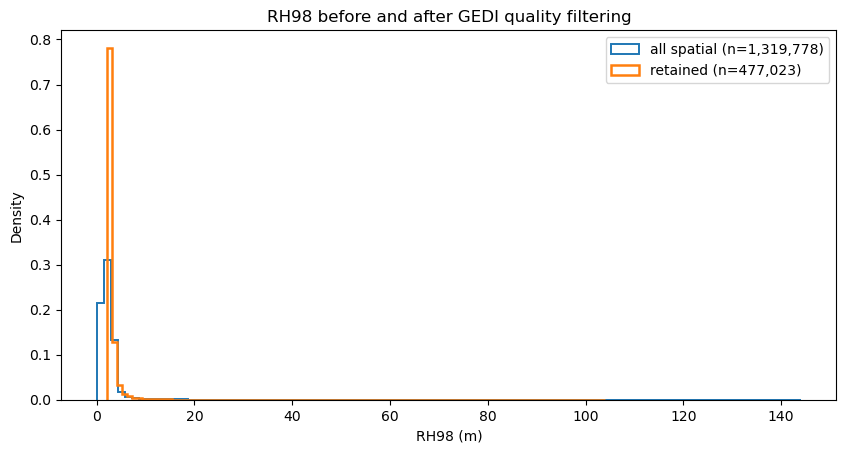

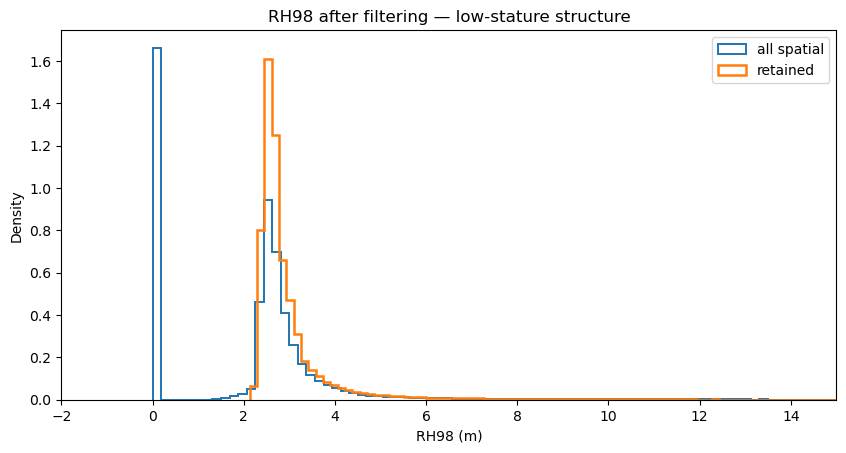

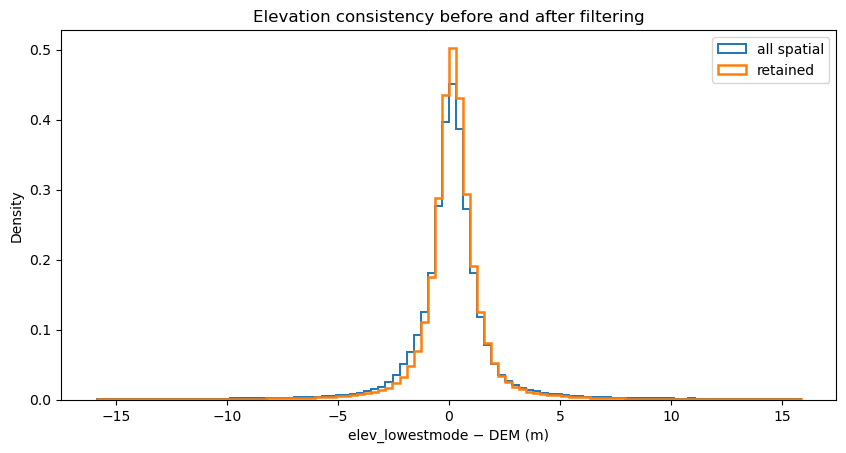

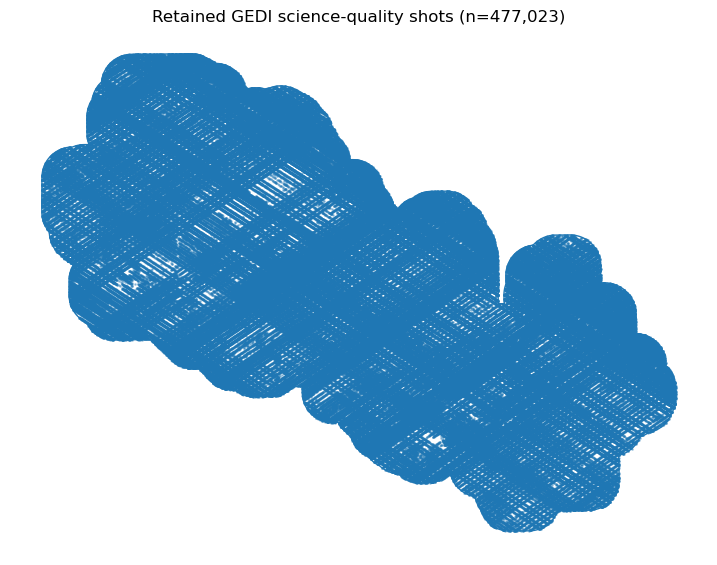

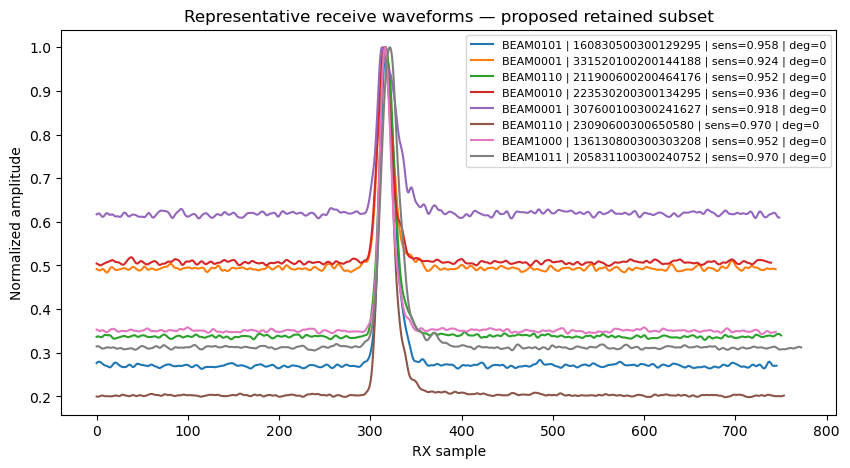


`gedi_keep` contains 477,023 retained shots.


In [24]:
# =============================================================================
# What does the retained GEDI population look like?
# =============================================================================

# -------------------------------------------------------------------------
# Summary statistics before vs after filtering
# -------------------------------------------------------------------------

compare_vars = [
    c for c in [
        "sensitivity",
        "rh50",
        "rh90",
        "rh95",
        "rh98",
        "rh100",
        "lowestmode_minus_dem_m",
        "l1b_l2a_horizontal_offset_m",
        "digital_elevation_model",
        "solar_elevation",
        "num_detectedmodes",
    ]
    if c in paired_shots.columns
]

summary_rows = []

for label, df in [
    ("all_spatial", paired_shots),
    ("retained", gedi_keep),
]:

    for col in compare_vars:

        x = (
            pd.to_numeric(
                df[col],
                errors="coerce",
            )
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
        )

        if x.empty:
            continue

        summary_rows.append(
            {
                "subset": label,
                "variable": col,
                "n": len(x),
                "p01": x.quantile(0.01),
                "p05": x.quantile(0.05),
                "median": x.median(),
                "mean": x.mean(),
                "p95": x.quantile(0.95),
                "p99": x.quantile(0.99),
            }
        )

filter_summary = pd.DataFrame(
    summary_rows
)

display(filter_summary)

# -------------------------------------------------------------------------
# RH98 before vs after filtering
# -------------------------------------------------------------------------

if "rh98" in paired_shots.columns:

    raw_rh98 = (
        pd.to_numeric(
            paired_shots["rh98"],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    keep_rh98 = (
        pd.to_numeric(
            gedi_keep["rh98"],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    fig, ax = plt.subplots(
        figsize=(10, 4.8)
    )

    ax.hist(
        raw_rh98,
        bins=100,
        histtype="step",
        linewidth=1.4,
        density=True,
        label=f"all spatial (n={len(raw_rh98):,})",
    )

    ax.hist(
        keep_rh98,
        bins=100,
        histtype="step",
        linewidth=1.8,
        density=True,
        label=f"retained (n={len(keep_rh98):,})",
    )

    ax.set_xlabel("RH98 (m)")
    ax.set_ylabel("Density")
    ax.set_title(
        "RH98 before and after GEDI quality filtering"
    )
    ax.legend()

    plt.show()

    # -------------------------------------------------------------
    # Zoom into the ecologically interesting low-stature range
    # -------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 4.8)
    )

    ax.hist(
        raw_rh98[
            (raw_rh98 >= -2)
            & (raw_rh98 <= 15)
        ],
        bins=80,
        histtype="step",
        linewidth=1.4,
        density=True,
        label="all spatial",
    )

    ax.hist(
        keep_rh98[
            (keep_rh98 >= -2)
            & (keep_rh98 <= 15)
        ],
        bins=80,
        histtype="step",
        linewidth=1.8,
        density=True,
        label="retained",
    )

    ax.set_xlim(-2, 15)
    ax.set_xlabel("RH98 (m)")
    ax.set_ylabel("Density")
    ax.set_title(
        "RH98 after filtering — low-stature structure"
    )
    ax.legend()

    plt.show()

# -------------------------------------------------------------------------
# DEM residual before vs after filtering
# -------------------------------------------------------------------------

if "lowestmode_minus_dem_m" in paired_shots.columns:

    raw_resid = (
        pd.to_numeric(
            paired_shots[
                "lowestmode_minus_dem_m"
            ],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    keep_resid = (
        pd.to_numeric(
            gedi_keep[
                "lowestmode_minus_dem_m"
            ],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    # Plot central retained range.
    # Full tails remain in filter_summary.
    lim = max(
        10,
        float(
            np.nanquantile(
                np.abs(keep_resid),
                0.995,
            )
        )
        if len(keep_resid)
        else 10,
    )

    fig, ax = plt.subplots(
        figsize=(10, 4.8)
    )

    ax.hist(
        raw_resid[
            (raw_resid >= -lim)
            & (raw_resid <= lim)
        ],
        bins=100,
        histtype="step",
        linewidth=1.4,
        density=True,
        label="all spatial",
    )

    ax.hist(
        keep_resid[
            (keep_resid >= -lim)
            & (keep_resid <= lim)
        ],
        bins=100,
        histtype="step",
        linewidth=1.8,
        density=True,
        label="retained",
    )

    ax.set_xlabel(
        "elev_lowestmode − DEM (m)"
    )
    ax.set_ylabel("Density")
    ax.set_title(
        "Elevation consistency before and after filtering"
    )
    ax.legend()

    plt.show()

# -------------------------------------------------------------------------
# Spatial coverage after filtering
# -------------------------------------------------------------------------

if {
    "longitude_l2a",
    "latitude_l2a",
}.issubset(
    gedi_keep.columns
):

    retained_xy = (
        gedi_keep
        .dropna(
            subset=[
                "longitude_l2a",
                "latitude_l2a",
            ]
        )
        .copy()
    )

    retained_gdf = gpd.GeoDataFrame(
        retained_xy,
        geometry=gpd.points_from_xy(
            retained_xy["longitude_l2a"],
            retained_xy["latitude_l2a"],
        ),
        crs="EPSG:4326",
    ).to_crs(
        aoi.crs
    )

    fig, ax = plt.subplots(
        figsize=(9, 9)
    )

    aoi.boundary.plot(
        ax=ax,
        linewidth=1,
    )

    retained_gdf.plot(
        ax=ax,
        markersize=1,
        alpha=0.35,
    )

    ax.set_title(
        f"Retained GEDI science-quality shots "
        f"(n={len(retained_gdf):,})"
    )

    ax.set_axis_off()

    plt.show()

# -------------------------------------------------------------------------
# Representative retained waveforms
# -------------------------------------------------------------------------

retained_examples = sample_rows(
    gedi_keep,
    pd.Series(
        True,
        index=gedi_keep.index,
    ),
    n=8,
)

if not retained_examples.empty:

    plot_waveform_class(
        retained_examples,
        "proposed retained subset",
    )

print(
    f"\n`gedi_keep` contains "
    f"{len(gedi_keep):,} retained shots."
)

In [25]:
# =============================================================================
# 10% sample of retained POWER-beam GEDI shots
# =============================================================================

POWER_BEAMS = {
    "BEAM0101",
    "BEAM0110",
    "BEAM1000",
    "BEAM1011",
}

POWER_SAMPLE_FRACTION = 0.10
POWER_SAMPLE_SEED = 42

# All retained science-quality power-beam shots
gedi_power = (
    gedi_keep.loc[
        gedi_keep["beam"].isin(POWER_BEAMS)
    ]
    .copy()
)

# Reproducible 10% random sample
gedi_power_10 = (
    gedi_power
    .sample(
        frac=POWER_SAMPLE_FRACTION,
        random_state=POWER_SAMPLE_SEED,
    )
    .reset_index(drop=True)
)

print("RETAINED POWER-BEAM SAMPLE")
print("--------------------------")
print(f"All retained shots:       {len(gedi_keep):,}")
print(f"Retained power shots:     {len(gedi_power):,}")
print(f"10% power-beam sample:    {len(gedi_power_10):,}")
print()

display(
    pd.DataFrame({
        "all_retained": gedi_keep["beam"].value_counts().sort_index(),
        "power_population": gedi_power["beam"].value_counts().sort_index(),
        "power_10pct": gedi_power_10["beam"].value_counts().sort_index(),
    }).fillna(0).astype(int)
)

RETAINED POWER-BEAM SAMPLE
--------------------------
All retained shots:       477,023
Retained power shots:     321,819
10% power-beam sample:    32,182



,all_retained,power_population,power_10pct
beam,,,
BEAM0000,29380,0,0
BEAM0001,32104,0,0
BEAM0010,43013,0,0
BEAM0011,50707,0,0
BEAM0101,80463,80463,8088
BEAM0110,81367,81367,8106
BEAM1000,79237,79237,7867
BEAM1011,80752,80752,8121


In [26]:
# =============================================================================
# Baseline-correct, normalize, and peak-align retained power waveforms
# =============================================================================

ALIGN_LEFT = 120
ALIGN_RIGHT = 180

# Use the outer portions of each waveform to estimate detector background.
BASELINE_EDGE_FRACTION = 0.15


def prepare_rx_for_shape(rx):
    """
    Convert a raw RX waveform into a waveform suitable for comparing shape:

      1. estimate background from waveform edges,
      2. subtract background,
      3. clip negative residuals to zero,
      4. normalize to unit maximum,
      5. return dominant-peak location.

    This is for morphology/Gaussian inspection, not preservation of
    absolute waveform energy.
    """

    rx = np.asarray(rx, dtype=float)

    if len(rx) < 20:
        return None

    n_edge = max(
        5,
        int(len(rx) * BASELINE_EDGE_FRACTION)
    )

    background_samples = np.concatenate([
        rx[:n_edge],
        rx[-n_edge:],
    ])

    baseline = np.nanmedian(background_samples)

    corrected = rx - baseline

    # For shape comparison, negative residuals are treated as background.
    corrected = np.clip(corrected, 0, None)

    peak = np.nanmax(corrected)

    if (
        not np.isfinite(peak)
        or peak <= 0
    ):
        return None

    normalized = corrected / peak

    peak_index = int(
        np.nanargmax(normalized)
    )

    return {
        "waveform": normalized,
        "peak_index": peak_index,
        "baseline": baseline,
        "raw_peak_above_baseline": peak,
    }


aligned_waveforms = []
waveform_metadata = []

relative_samples = np.arange(
    -ALIGN_LEFT,
    ALIGN_RIGHT + 1,
)


for i, row in gedi_power_10.iterrows():

    try:

        rx, _ = load_l1b_waveforms(
            l1b_path_for_key(
                row["granule_key"]
            ),
            row["beam"],
            row["shot_number"],
        )

    except Exception:
        continue

    if rx is None:
        continue

    prepared = prepare_rx_for_shape(rx)

    if prepared is None:
        continue

    wf = prepared["waveform"]
    peak_idx = prepared["peak_index"]

    start = peak_idx - ALIGN_LEFT
    stop = peak_idx + ALIGN_RIGHT + 1

    # Require the complete alignment window.
    if (
        start < 0
        or stop > len(wf)
    ):
        continue

    aligned = wf[start:stop]

    aligned_waveforms.append(aligned)

    waveform_metadata.append({
        "granule_key": row["granule_key"],
        "beam": row["beam"],
        "shot_number": row["shot_number"],
        "sensitivity": row["sensitivity"],
        "rh98": row["rh98"]
            if "rh98" in row.index
            else np.nan,
        "baseline": prepared["baseline"],
        "peak_above_baseline":
            prepared["raw_peak_above_baseline"],
    })


aligned_waveforms = np.asarray(
    aligned_waveforms
)

waveform_metadata = pd.DataFrame(
    waveform_metadata
)

print(
    f"Successfully aligned "
    f"{len(aligned_waveforms):,} / "
    f"{len(gedi_power_10):,} sampled waveforms"
)

print(
    "Aligned matrix:",
    aligned_waveforms.shape
)

Successfully aligned 32,180 / 32,182 sampled waveforms
Aligned matrix: (32180, 301)


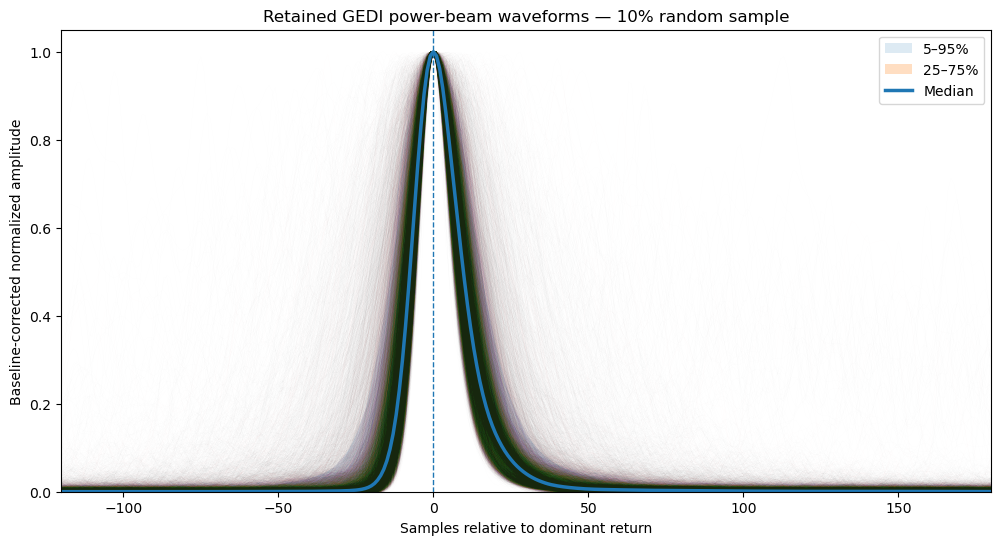

In [27]:
# =============================================================================
# All 10% sampled power-beam waveforms in one aligned plot
# =============================================================================

if len(aligned_waveforms) == 0:
    raise RuntimeError(
        "No aligned waveforms available."
    )

# Population summaries
wf_median = np.nanmedian(
    aligned_waveforms,
    axis=0,
)

wf_q25 = np.nanquantile(
    aligned_waveforms,
    0.25,
    axis=0,
)

wf_q75 = np.nanquantile(
    aligned_waveforms,
    0.75,
    axis=0,
)

wf_q05 = np.nanquantile(
    aligned_waveforms,
    0.05,
    axis=0,
)

wf_q95 = np.nanquantile(
    aligned_waveforms,
    0.95,
    axis=0,
)


fig, ax = plt.subplots(
    figsize=(12, 6)
)

# Every waveform
for wf in aligned_waveforms:

    ax.plot(
        relative_samples,
        wf,
        alpha=0.008,
        linewidth=0.35,
        rasterized=True,
    )

# 90% envelope
ax.fill_between(
    relative_samples,
    wf_q05,
    wf_q95,
    alpha=0.15,
    label="5–95%",
)

# IQR
ax.fill_between(
    relative_samples,
    wf_q25,
    wf_q75,
    alpha=0.25,
    label="25–75%",
)

# Median waveform
ax.plot(
    relative_samples,
    wf_median,
    linewidth=2.5,
    label="Median",
)

ax.axvline(
    0,
    linewidth=1,
    linestyle="--",
)

ax.set_xlim(
    -ALIGN_LEFT,
    ALIGN_RIGHT,
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_xlabel(
    "Samples relative to dominant return"
)

ax.set_ylabel(
    "Baseline-corrected normalized amplitude"
)

ax.set_title(
    "Retained GEDI power-beam waveforms — "
    "10% random sample"
)

ax.legend()

plt.show()

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
rh50,32182.0,-0.112598,1.110165,-2.92,-0.48,-0.26,-0.26,-0.22,-0.18,-0.14,-0.07,0.00,0.8600,67.550003
rh75,32182.0,1.017093,2.325117,-0.22,0.67,0.71,0.71,0.74,0.78,0.86,1.08,1.38,4.0438,82.870003
rh90,32182.0,2.017784,3.221383,1.16,1.42,1.46,1.49,1.53,1.61,1.79,2.16,2.80,8.0857,90.209999
rh95,32182.0,2.585903,3.529814,1.72,1.83,1.90,1.94,1.98,2.09,2.32,2.87,3.74,10.0776,93.510002
rh98,32182.0,3.191023,3.736620,2.17,2.28,2.35,2.39,2.47,2.61,2.91,3.70,4.92,11.7476,96.089996
rh100,32182.0,4.354294,3.856835,2.88,3.14,3.29,3.37,3.48,3.70,4.10,5.17,6.93,13.7019,97.849998


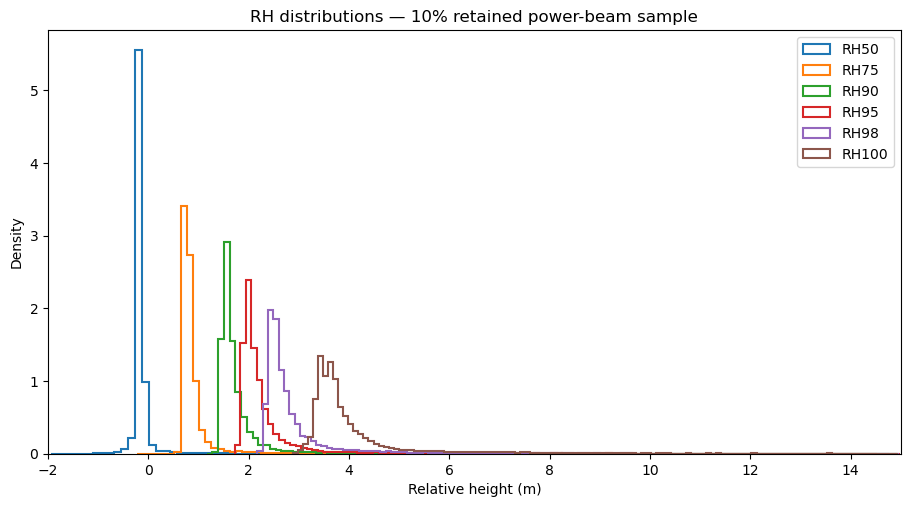

In [28]:
# =============================================================================
# RH distributions for retained power shots and the 10% waveform sample
# =============================================================================

RH_PLOT_COLS = [
    "rh50",
    "rh75",
    "rh90",
    "rh95",
    "rh98",
    "rh100",
]

RH_PLOT_COLS = [
    c for c in RH_PLOT_COLS
    if c in gedi_power_10.columns
]


# -------------------------------------------------------------------------
# Descriptive table
# -------------------------------------------------------------------------

rh_summary = (
    gedi_power_10[RH_PLOT_COLS]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)

display(rh_summary)


# -------------------------------------------------------------------------
# Overlay RH distributions
# -------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 5.5)
)

for col in RH_PLOT_COLS:

    x = (
        pd.to_numeric(
            gedi_power_10[col],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    # Focus on low-stature structure while retaining
    # the numerical tails in the summary table above.
    x = x[
        (x >= -2)
        & (x <= 15)
    ]

    ax.hist(
        x,
        bins=120,
        histtype="step",
        density=True,
        linewidth=1.5,
        label=col.upper(),
    )

ax.set_xlim(
    -2,
    15,
)

ax.set_xlabel(
    "Relative height (m)"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "RH distributions — 10% retained power-beam sample"
)

ax.legend()

plt.show()

In [29]:
# =============================================================================
# Check representativeness of the 10% power sample
# =============================================================================

rows = []

for col in RH_PLOT_COLS:

    for label, df in [
        ("all retained power", gedi_power),
        ("10% power sample", gedi_power_10),
    ]:

        x = pd.to_numeric(
            df[col],
            errors="coerce",
        ).dropna()

        rows.append({
            "subset": label,
            "metric": col,
            "n": len(x),
            "median": x.median(),
            "p25": x.quantile(0.25),
            "p75": x.quantile(0.75),
            "p95": x.quantile(0.95),
            "p99": x.quantile(0.99),
        })

display(
    pd.DataFrame(rows)
)

,subset,metric,n,median,p25,p75,p95,p99
0,all retained power,rh50,321819,-0.18,-0.22,-0.14,0.00,0.9300
1,10% power sample,rh50,32182,-0.18,-0.22,-0.14,0.00,0.8600
2,all retained power,rh75,321819,0.78,0.74,0.86,1.38,4.2300
3,10% power sample,rh75,32182,0.78,0.74,0.86,1.38,4.0438
4,all retained power,rh90,321819,1.61,1.53,1.79,2.83,7.9200
5,10% power sample,rh90,32182,1.61,1.53,1.79,2.80,8.0857
6,all retained power,rh95,321819,2.09,1.98,2.34,3.76,9.9082
7,10% power sample,rh95,32182,2.09,1.98,2.32,3.74,10.0776
8,all retained power,rh98,321819,2.61,2.47,2.91,4.94,11.6000
9,10% power sample,rh98,32182,2.61,2.47,2.91,4.92,11.7476


In [30]:
# =============================================================================
# Raw RX waveforms — peak aligned, NOT normalized
# =============================================================================

RAW_ALIGN_LEFT = 120
RAW_ALIGN_RIGHT = 180

raw_aligned_waveforms = []
raw_waveform_metadata = []

relative_samples_raw = np.arange(
    -RAW_ALIGN_LEFT,
    RAW_ALIGN_RIGHT + 1,
)

for _, row in gedi_power_10.iterrows():

    try:
        rx, _ = load_l1b_waveforms(
            l1b_path_for_key(
                row["granule_key"]
            ),
            row["beam"],
            row["shot_number"],
        )

    except Exception:
        continue

    if rx is None:
        continue

    rx = np.asarray(rx, dtype=float)

    if len(rx) < 20:
        continue

    # Align using dominant raw return
    peak_idx = int(
        np.nanargmax(rx)
    )

    start = peak_idx - RAW_ALIGN_LEFT
    stop = peak_idx + RAW_ALIGN_RIGHT + 1

    if (
        start < 0
        or stop > len(rx)
    ):
        continue

    aligned = rx[start:stop]

    raw_aligned_waveforms.append(
        aligned
    )

    raw_waveform_metadata.append({
        "granule_key": row["granule_key"],
        "beam": row["beam"],
        "shot_number": row["shot_number"],
        "sensitivity": row["sensitivity"],
        "rh98": row["rh98"]
            if "rh98" in row.index
            else np.nan,
        "raw_peak": np.nanmax(rx),
        "raw_median": np.nanmedian(rx),
    })

raw_aligned_waveforms = np.asarray(
    raw_aligned_waveforms
)

raw_waveform_metadata = pd.DataFrame(
    raw_waveform_metadata
)

print(
    f"Aligned raw waveforms: "
    f"{len(raw_aligned_waveforms):,}"
)

print(
    "Matrix shape:",
    raw_aligned_waveforms.shape
)

Aligned raw waveforms: 32,180
Matrix shape: (32180, 301)


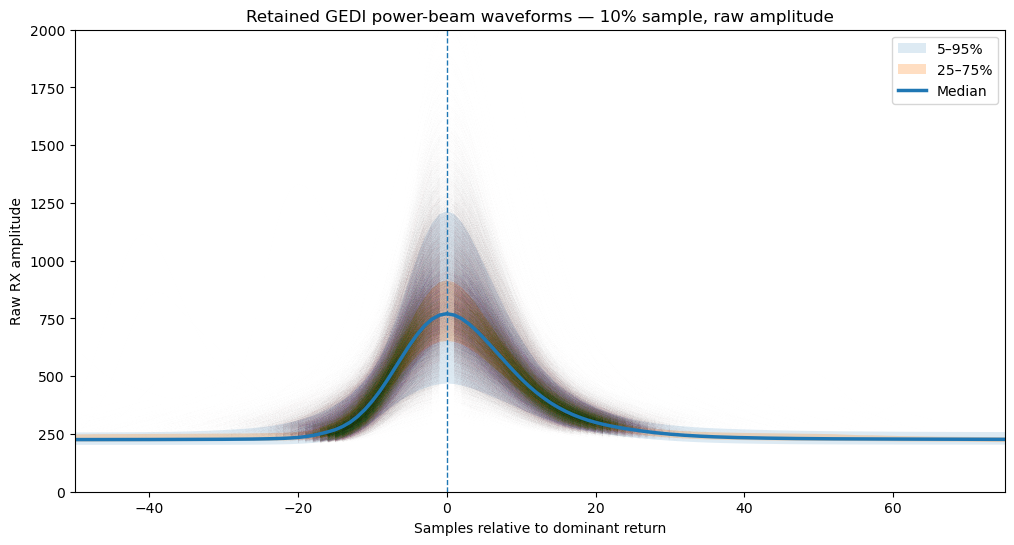

In [31]:
# =============================================================================
# Raw-amplitude waveform overlay
# =============================================================================

if len(raw_aligned_waveforms) == 0:
    raise RuntimeError(
        "No raw aligned waveforms available."
    )

raw_median = np.nanmedian(
    raw_aligned_waveforms,
    axis=0,
)

raw_q25 = np.nanquantile(
    raw_aligned_waveforms,
    0.25,
    axis=0,
)

raw_q75 = np.nanquantile(
    raw_aligned_waveforms,
    0.75,
    axis=0,
)

raw_q05 = np.nanquantile(
    raw_aligned_waveforms,
    0.05,
    axis=0,
)

raw_q95 = np.nanquantile(
    raw_aligned_waveforms,
    0.95,
    axis=0,
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

for wf in raw_aligned_waveforms:

    ax.plot(
        relative_samples_raw,
        wf,
        alpha=0.004,
        linewidth=0.35,
        rasterized=True,
    )

ax.fill_between(
    relative_samples_raw,
    raw_q05,
    raw_q95,
    alpha=0.15,
    label="5–95%",
)

ax.fill_between(
    relative_samples_raw,
    raw_q25,
    raw_q75,
    alpha=0.25,
    label="25–75%",
)

ax.plot(
    relative_samples_raw,
    raw_median,
    linewidth=2.5,
    label="Median",
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Samples relative to dominant return"
)

ax.set_ylabel(
    "Raw RX amplitude"
)

ax.set_title(
    "Retained GEDI power-beam waveforms — "
    "10% sample, raw amplitude"
)
ax.set_ylim(0, 2000)
ax.set_xlim(-50, 75)
ax.legend()

plt.show()

In [32]:
# =============================================================================
# Baseline-corrected RX waveforms — peak aligned, NOT normalized
# =============================================================================

BASELINE_EDGE_FRACTION = 0.15

corrected_aligned_waveforms = []
corrected_waveform_metadata = []

for _, row in gedi_power_10.iterrows():

    try:
        rx, _ = load_l1b_waveforms(
            l1b_path_for_key(
                row["granule_key"]
            ),
            row["beam"],
            row["shot_number"],
        )

    except Exception:
        continue

    if rx is None:
        continue

    rx = np.asarray(rx, dtype=float)

    if len(rx) < 20:
        continue

    n_edge = max(
        5,
        int(
            len(rx)
            * BASELINE_EDGE_FRACTION
        )
    )

    background_samples = np.concatenate([
        rx[:n_edge],
        rx[-n_edge:],
    ])

    baseline = np.nanmedian(
        background_samples
    )

    corrected = (
        rx - baseline
    )

    # Do NOT normalize amplitude.
    # Keep negative noise excursions too.
    peak_idx = int(
        np.nanargmax(corrected)
    )

    start = (
        peak_idx
        - RAW_ALIGN_LEFT
    )

    stop = (
        peak_idx
        + RAW_ALIGN_RIGHT
        + 1
    )

    if (
        start < 0
        or stop > len(corrected)
    ):
        continue

    aligned = corrected[start:stop]

    corrected_aligned_waveforms.append(
        aligned
    )

    corrected_waveform_metadata.append({
        "granule_key": row["granule_key"],
        "beam": row["beam"],
        "shot_number": row["shot_number"],
        "sensitivity": row["sensitivity"],
        "rh98": row["rh98"]
            if "rh98" in row.index
            else np.nan,
        "baseline": baseline,
        "peak_above_baseline":
            np.nanmax(corrected),
    })

corrected_aligned_waveforms = np.asarray(
    corrected_aligned_waveforms
)

corrected_waveform_metadata = pd.DataFrame(
    corrected_waveform_metadata
)

print(
    f"Baseline-corrected aligned waveforms: "
    f"{len(corrected_aligned_waveforms):,}"
)

Baseline-corrected aligned waveforms: 32,180


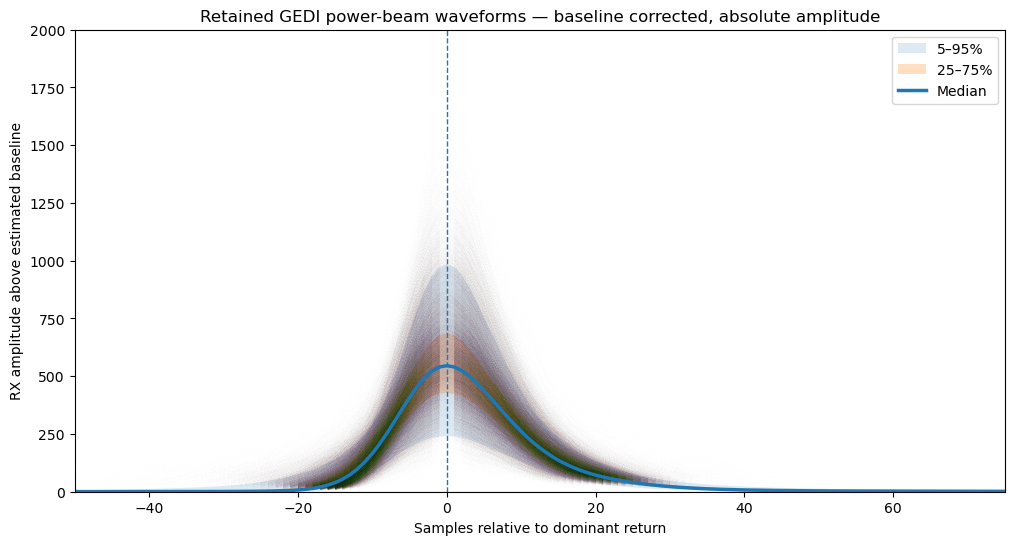

In [33]:
# =============================================================================
# Baseline-corrected absolute waveform overlay
# =============================================================================

corr_median = np.nanmedian(
    corrected_aligned_waveforms,
    axis=0,
)

corr_q25 = np.nanquantile(
    corrected_aligned_waveforms,
    0.25,
    axis=0,
)

corr_q75 = np.nanquantile(
    corrected_aligned_waveforms,
    0.75,
    axis=0,
)

corr_q05 = np.nanquantile(
    corrected_aligned_waveforms,
    0.05,
    axis=0,
)

corr_q95 = np.nanquantile(
    corrected_aligned_waveforms,
    0.95,
    axis=0,
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

for wf in corrected_aligned_waveforms:

    ax.plot(
        relative_samples_raw,
        wf,
        alpha=0.004,
        linewidth=0.35,
        rasterized=True,
    )

ax.fill_between(
    relative_samples_raw,
    corr_q05,
    corr_q95,
    alpha=0.15,
    label="5–95%",
)

ax.fill_between(
    relative_samples_raw,
    corr_q25,
    corr_q75,
    alpha=0.25,
    label="25–75%",
)

ax.plot(
    relative_samples_raw,
    corr_median,
    linewidth=2.5,
    label="Median",
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Samples relative to dominant return"
)

ax.set_ylabel(
    "RX amplitude above estimated baseline"
)

ax.set_title(
    "Retained GEDI power-beam waveforms — "
    "baseline corrected, absolute amplitude"
)
ax.set_ylim(0, 2000)
ax.set_xlim(-50, 75)
ax.legend()

plt.show()

In [34]:
# =============================================================================
# GEDI L2A detected-mode distribution in retained NCA shots
# =============================================================================

mode_counts = (
    gedi_keep["num_detectedmodes"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("n")
    .to_frame()
)

mode_counts["percent"] = (
    100 * mode_counts["n"] / mode_counts["n"].sum()
)

display(mode_counts)

print(
    "Shots with >=2 GEDI-detected modes:",
    f"{(gedi_keep['num_detectedmodes'] >= 2).sum():,}"
)

print(
    "Percent with >=2 GEDI-detected modes:",
    f"{100 * (gedi_keep['num_detectedmodes'] >= 2).mean():.3f}%"
)

,n,percent
num_detectedmodes,,
1,472352,99.020802
2,3857,0.808556
3,676,0.141712
4,116,0.024317
5,18,0.003773
6,4,0.000839


Shots with >=2 GEDI-detected modes: 4,671
Percent with >=2 GEDI-detected modes: 0.979%


In [35]:
# =============================================================================
# Peak detection + constrained Gaussian mixture fitting
# =============================================================================

from scipy.signal import find_peaks, peak_widths
from scipy.optimize import least_squares

MAX_COMPONENTS = 7

BASELINE_EDGE_FRACTION = 0.15

# Peak detection controls
MIN_PEAK_DISTANCE = 3          # samples
MIN_PEAK_WIDTH = 1.0           # samples

# Require prominence relative to measured background noise.
PROMINENCE_NOISE_MULTIPLIER = 4.0

# Prevent pathological Gaussian collapse
MIN_SIGMA_SAMPLES = 0.75
MAX_SIGMA_SAMPLES = 100.0


def gaussian_sum(x, params):
    """
    params = [A1, mu1, sigma1, A2, mu2, sigma2, ...]
    """
    y = np.zeros_like(x, dtype=float)

    for k in range(len(params) // 3):

        A = params[3*k]
        mu = params[3*k + 1]
        sigma = params[3*k + 2]

        y += A * np.exp(
            -0.5 * ((x - mu) / sigma) ** 2
        )

    return y


def prepare_waveform(rx):
    """
    Estimate baseline and background noise.
    Preserve negative residuals for fitting diagnostics.
    """

    rx = np.asarray(rx, dtype=float)

    if len(rx) < 20:
        return None

    n_edge = max(
        5,
        int(len(rx) * BASELINE_EDGE_FRACTION)
    )

    background = np.concatenate([
        rx[:n_edge],
        rx[-n_edge:],
    ])

    baseline = np.nanmedian(background)

    # Robust estimate of background noise
    mad = np.nanmedian(
        np.abs(background - baseline)
    )

    noise_sigma = 1.4826 * mad

    corrected = rx - baseline

    return {
        "corrected": corrected,
        "baseline": baseline,
        "noise_sigma": noise_sigma,
    }


def detect_waveform_peaks(corrected, noise_sigma):
    """
    Detect candidate waveform modes.

    Prominence threshold scales with empirical background noise.
    """

    if (
        not np.isfinite(noise_sigma)
        or noise_sigma <= 0
    ):
        noise_sigma = np.nanstd(corrected)

    prominence_threshold = (
        PROMINENCE_NOISE_MULTIPLIER
        * noise_sigma
    )

    peaks, properties = find_peaks(
        corrected,
        prominence=prominence_threshold,
        distance=MIN_PEAK_DISTANCE,
        width=MIN_PEAK_WIDTH,
    )

    if len(peaks) == 0:
        # Preserve at least the dominant valid return.
        peaks = np.array(
            [int(np.nanargmax(corrected))]
        )

        properties = {}

    # If >7 peaks are found, retain the seven most prominent.
    if len(peaks) > MAX_COMPONENTS:

        prominences = properties["prominences"]

        keep = np.argsort(
            prominences
        )[-MAX_COMPONENTS:]

        peaks = peaks[keep]

        # Restore height order
        peaks = np.sort(peaks)

    return peaks


def initialize_components(corrected, peaks):
    """
    Initialize A, mu, sigma from detected peaks.
    """

    x = np.arange(
        len(corrected),
        dtype=float,
    )

    # Estimate widths at half prominence.
    widths = peak_widths(
        corrected,
        peaks,
        rel_height=0.5,
    )[0]

    params = []

    for peak, width in zip(
        peaks,
        widths,
    ):

        A = max(
            corrected[peak],
            1e-6,
        )

        mu = float(peak)

        # Gaussian FWHM = 2.355 sigma
        sigma = max(
            float(width) / 2.35482,
            MIN_SIGMA_SAMPLES,
        )

        params.extend([
            A,
            mu,
            sigma,
        ])

    return np.asarray(
        params,
        dtype=float,
    )


def fit_waveform_gaussian_mixture(rx):
    """
    Detect waveform peaks and fit K Gaussians jointly.

    K is determined by peak detection, capped at 7.
    """

    prep = prepare_waveform(rx)

    if prep is None:
        return None

    corrected = prep["corrected"]
    baseline = prep["baseline"]
    noise_sigma = prep["noise_sigma"]

    x = np.arange(
        len(corrected),
        dtype=float,
    )

    peaks = detect_waveform_peaks(
        corrected,
        noise_sigma,
    )

    K = len(peaks)

    p0 = initialize_components(
        corrected,
        peaks,
    )

    lower = []
    upper = []

    for k in range(K):

        lower.extend([
            0.0,                  # amplitude
            0.0,                  # centroid
            MIN_SIGMA_SAMPLES,    # width
        ])

        upper.extend([
            np.inf,
            len(corrected) - 1,
            MAX_SIGMA_SAMPLES,
        ])

    lower = np.asarray(lower)
    upper = np.asarray(upper)

    def residuals(params):
        return (
            corrected
            - gaussian_sum(
                x,
                params,
            )
        )

    fit = least_squares(
        residuals,
        p0,
        bounds=(
            lower,
            upper,
        ),
        method="trf",
    )

    params = fit.x

    fitted = gaussian_sum(
        x,
        params,
    )

    residual = (
        corrected
        - fitted
    )

    ss_res = np.sum(
        residual ** 2
    )

    ss_tot = np.sum(
        (
            corrected
            - np.mean(corrected)
        ) ** 2
    )

    r2 = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    rmse = np.sqrt(
        np.mean(
            residual ** 2
        )
    )

    components = []

    for k in range(K):

        A = params[3*k]
        mu = params[3*k + 1]
        sigma = params[3*k + 2]

        area = (
            A
            * sigma
            * np.sqrt(2 * np.pi)
        )

        components.append({
            "component": k + 1,
            "amplitude": A,
            "mu_samples": mu,
            "sigma_samples": sigma,
            "fwhm_samples":
                2.35482 * sigma,
            "component_area": area,
        })

    return {
        "K_detected": K,
        "baseline": baseline,
        "noise_sigma": noise_sigma,
        "r2": r2,
        "rmse": rmse,
        "components": components,
    }

In [36]:
# =============================================================================
# Gaussian decomposition of ALL retained NCA shots
# =============================================================================

from tqdm.auto import tqdm

fit_rows = []
component_rows = []

grouped = (
    gedi_keep
    .groupby(
        ["granule_key", "beam"],
        sort=False,
    )
)

for (
    granule_key,
    beam,
), group in tqdm(
    grouped,
    desc="NCA Gaussian decomposition",
):

    l1b_path = l1b_path_for_key(
        granule_key
    )

    with h5py.File(
        l1b_path,
        "r",
    ) as h5:

        if beam not in h5:
            continue

        g = h5[beam]

        required = [
            "shot_number",
            "rxwaveform",
            "rx_sample_start_index",
            "rx_sample_count",
        ]

        if not all(
            name in g
            for name in required
        ):
            continue

        shots = np.asarray(
            g["shot_number"]
        )

        starts = np.asarray(
            g["rx_sample_start_index"]
        ).astype(np.int64)

        counts = np.asarray(
            g["rx_sample_count"]
        ).astype(np.int64)

        waveform_ds = g["rxwaveform"]

        shot_to_idx = {
            int(s): i
            for i, s in enumerate(shots)
        }

        for _, row in group.iterrows():

            shot_number = int(
                row["shot_number"]
            )

            i = shot_to_idx.get(
                shot_number
            )

            if i is None:
                continue

            start = (
                int(starts[i])
                - 1
            )

            count = int(
                counts[i]
            )

            stop = (
                start + count
            )

            if (
                start < 0
                or count <= 0
                or stop > len(waveform_ds)
            ):
                continue

            rx = np.asarray(
                waveform_ds[
                    start:stop
                ],
                dtype=float,
            )

            result = (
                fit_waveform_gaussian_mixture(
                    rx
                )
            )

            if result is None:
                continue

            fit_rows.append({
                "granule_key":
                    granule_key,

                "beam":
                    beam,

                "shot_number":
                    row["shot_number"],

                "GEDI_num_detectedmodes":
                    row.get(
                        "num_detectedmodes",
                        np.nan,
                    ),

                "K_detected":
                    result["K_detected"],

                "baseline":
                    result["baseline"],

                "noise_sigma":
                    result["noise_sigma"],

                "r2":
                    result["r2"],

                "rmse":
                    result["rmse"],

                "sensitivity":
                    row.get(
                        "sensitivity",
                        np.nan,
                    ),

                "rh98":
                    row.get(
                        "rh98",
                        np.nan,
                    ),
            })

            for comp in result[
                "components"
            ]:

                component_rows.append({
                    "granule_key":
                        granule_key,

                    "beam":
                        beam,

                    "shot_number":
                        row["shot_number"],

                    "K_detected":
                        result["K_detected"],

                    **comp,
                })


waveform_fits = pd.DataFrame(
    fit_rows
)

gaussian_components = pd.DataFrame(
    component_rows
)

print()
print("NCA decomposition complete")
print("--------------------------")
print(
    f"Retained shots: "
    f"{len(gedi_keep):,}"
)
print(
    f"Successfully fitted: "
    f"{len(waveform_fits):,}"
)

display(
    waveform_fits.head()
)

display(
    gaussian_components.head()
)

NCA Gaussian decomposition:   0%|          | 0/891 [00:00<?, ?it/s]


NCA decomposition complete
--------------------------
Retained shots: 477,023
Successfully fitted: 477,023


,granule_key,beam,shot_number,GEDI_num_detectedmodes,K_detected,baseline,noise_sigma,r2,rmse,sensitivity,rh98
0,O02061_02_T00905_02,BEAM0000,20610000200092327,1,3,245.149925,2.378390,0.990138,3.560509,0.902113,2.69
1,O02061_02_T00905_02,BEAM0000,20610000200092328,1,5,245.767235,1.977268,0.985924,5.113767,0.923635,2.43
2,O02061_02_T00905_02,BEAM0000,20610000200092329,1,5,245.214005,1.855976,0.991565,4.315295,0.930495,2.62
3,O02061_02_T00905_02,BEAM0000,20610000200092330,1,2,245.759277,2.266114,0.992612,4.754453,0.937379,2.50
4,O02061_02_T00905_02,BEAM0000,20610000200092331,1,6,245.046730,1.813310,0.988608,5.801782,0.941500,2.54


,granule_key,beam,shot_number,K_detected,component,amplitude,mu_samples,sigma_samples,fwhm_samples,component_area
0,O02061_02_T00905_02,BEAM0000,20610000200092327,3,1,291.382356,316.532460,6.473723,15.244452,4728.324510
1,O02061_02_T00905_02,BEAM0000,20610000200092327,3,2,7.856772,585.080149,2.500519,5.888272,49.245234
2,O02061_02_T00905_02,BEAM0000,20610000200092327,3,3,7.113876,657.417278,3.471985,8.175901,61.911900
3,O02061_02_T00905_02,BEAM0000,20610000200092328,5,1,6.090074,181.435121,2.316492,5.454921,35.362528
4,O02061_02_T00905_02,BEAM0000,20610000200092328,5,2,348.670244,315.683525,6.622717,15.595307,5788.166766


In [37]:
# =============================================================================
# Our Gaussian mode count versus GEDI L2A num_detectedmodes
# =============================================================================

comparison = pd.crosstab(
    waveform_fits[
        "GEDI_num_detectedmodes"
    ],
    waveform_fits[
        "K_detected"
    ],
    margins=True,
)

display(comparison)

print("\nOur fitted K distribution:")

display(
    waveform_fits[
        "K_detected"
    ]
    .value_counts()
    .sort_index()
    .rename("n")
    .to_frame()
    .assign(
        percent=lambda d:
            100
            * d["n"]
            / d["n"].sum()
    )
)

K_detected,1,2,3,4,5,6,7,All
GEDI_num_detectedmodes,,,,,,,,
1,27298,57059,75862,79245,69853,55269,107766,472352
2,12,158,330,508,497,542,1810,3857
3,5,5,26,47,81,111,401,676
4,0,0,0,1,15,10,90,116
5,0,0,0,1,0,2,15,18
6,0,0,0,0,1,0,3,4
All,27315,57222,76218,79802,70447,55934,110085,477023



Our fitted K distribution:


,n,percent
K_detected,,
1,27315,5.726139
2,57222,11.995648
3,76218,15.977846
4,79802,16.729172
5,70447,14.768051
6,55934,11.725640
7,110085,23.077504


In [38]:
# =============================================================================
# SAVE CURRENT NCA GAUSSIAN FIT OUTPUTS
#
# These are the ORIGINAL independent-peak-detection results.
# Preserve them as a diagnostic before replacing K with GEDI num_detectedmodes.
# =============================================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np

FIT_OUTPUT_DIR = (
    SUBSET_ROOT
    / "derived_waveform_fits"
)

FIT_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ORIGINAL_FIT_PATH = (
    FIT_OUTPUT_DIR
    / "NCA_gaussian_fits_independent_peakK.pkl"
)

ORIGINAL_COMPONENT_PATH = (
    FIT_OUTPUT_DIR
    / "NCA_gaussian_components_independent_peakK.pkl"
)

ORIGINAL_METADATA_PATH = (
    FIT_OUTPUT_DIR
    / "NCA_gaussian_fits_independent_peakK_metadata.json"
)

# ---------------------------------------------------------------------
# Save exact pandas objects.
# Pickle avoids requiring pyarrow and preserves dtypes/index reliably.
# ---------------------------------------------------------------------

waveform_fits.to_pickle(
    ORIGINAL_FIT_PATH
)

gaussian_components.to_pickle(
    ORIGINAL_COMPONENT_PATH
)

metadata = {
    "description":
        "Original NCA Gaussian decomposition using independently "
        "detected peaks to determine K. This run substantially "
        "over-detected modes and is retained for diagnostic comparison.",

    "n_retained_shots":
        int(len(gedi_keep)),

    "n_successful_waveform_fits":
        int(len(waveform_fits)),

    "n_gaussian_components":
        int(len(gaussian_components)),

    "K_distribution":
        {
            str(k): int(v)
            for k, v in (
                waveform_fits[
                    "K_detected"
                ]
                .value_counts()
                .sort_index()
                .items()
            )
        },

    "gedi_mode_distribution":
        {
            str(k): int(v)
            for k, v in (
                gedi_keep[
                    "num_detectedmodes"
                ]
                .value_counts()
                .sort_index()
                .items()
            )
        },
}

with open(
    ORIGINAL_METADATA_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
    )

print("SAVED ORIGINAL FIT RESULTS")
print("--------------------------")
print(ORIGINAL_FIT_PATH)
print(ORIGINAL_COMPONENT_PATH)
print(ORIGINAL_METADATA_PATH)

print()
print(
    f"Waveform fits: "
    f"{len(waveform_fits):,}"
)

print(
    f"Gaussian components: "
    f"{len(gaussian_components):,}"
)

print()
print(
    "These files can be reloaded after a "
    "kernel restart with:"
)

print(
    'waveform_fits = pd.read_pickle('
    'ORIGINAL_FIT_PATH)'
)

print(
    'gaussian_components = pd.read_pickle('
    'ORIGINAL_COMPONENT_PATH)'
)

SAVED ORIGINAL FIT RESULTS
--------------------------
A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\derived_waveform_fits\NCA_gaussian_fits_independent_peakK.pkl
A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\derived_waveform_fits\NCA_gaussian_components_independent_peakK.pkl
A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\derived_waveform_fits\NCA_gaussian_fits_independent_peakK_metadata.json

Waveform fits: 477,023
Gaussian components: 2,148,055

These files can be reloaded after a kernel restart with:
waveform_fits = pd.read_pickle(ORIGINAL_FIT_PATH)
gaussian_components = pd.read_pickle(ORIGINAL_COMPONENT_PATH)


In [39]:
# =============================================================================
# NCA GAUSSIAN DECOMPOSITION — GEDI num_detectedmodes DEFINES K
#
# GEDI L2A num_detectedmodes determines the number of Gaussian components.
# L1B waveform peak structure is used ONLY to initialize component locations.
#
# Results are checkpointed by granule/beam so this cell can resume safely
# after a kernel restart.
# =============================================================================

import json
import h5py
import numpy as np
import pandas as pd

from pathlib import Path

from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, peak_widths
from scipy.optimize import least_squares

from tqdm.auto import tqdm


# =============================================================================
# OUTPUT / CHECKPOINT PATHS
# =============================================================================

RESOLVED_DIR = (
    FIT_OUTPUT_DIR
    / "GEDI_mode_constrained"
)

RESOLVED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIT_CHECKPOINT = (
    RESOLVED_DIR
    / "NCA_waveform_fits_GEDI_K_checkpoint.pkl"
)

COMPONENT_CHECKPOINT = (
    RESOLVED_DIR
    / "NCA_gaussian_components_GEDI_K_checkpoint.pkl"
)

PROGRESS_CHECKPOINT = (
    RESOLVED_DIR
    / "NCA_GEDI_K_progress.json"
)

FINAL_FIT_PATH = (
    RESOLVED_DIR
    / "NCA_waveform_fits_GEDI_K.pkl"
)

FINAL_COMPONENT_PATH = (
    RESOLVED_DIR
    / "NCA_gaussian_components_GEDI_K.pkl"
)


# =============================================================================
# FIT SETTINGS
# =============================================================================

MAX_COMPONENTS = 7

BASELINE_EDGE_FRACTION = 0.15

# Smoothing is ONLY for locating initialization peaks.
# The actual fit uses the unsmoothed baseline-corrected waveform.
INITIALIZATION_SMOOTH_SIGMA = 1.5

MIN_INITIAL_PEAK_DISTANCE = 3

MIN_SIGMA_SAMPLES = 0.75
MAX_SIGMA_SAMPLES = 100.0


# =============================================================================
# GAUSSIAN MODEL
# =============================================================================

def gaussian_sum(x, params):

    y = np.zeros_like(
        x,
        dtype=float,
    )

    K = len(params) // 3

    for k in range(K):

        A = params[3*k]
        mu = params[3*k + 1]
        sigma = params[3*k + 2]

        y += (
            A
            * np.exp(
                -0.5
                * (
                    (x - mu)
                    / sigma
                ) ** 2
            )
        )

    return y


# =============================================================================
# BASELINE CORRECTION
# =============================================================================

def prepare_waveform_fixedK(rx):

    rx = np.asarray(
        rx,
        dtype=float,
    )

    if len(rx) < 20:
        return None

    if not np.isfinite(rx).all():
        return None

    n_edge = max(
        5,
        int(
            len(rx)
            * BASELINE_EDGE_FRACTION
        ),
    )

    background = np.concatenate([
        rx[:n_edge],
        rx[-n_edge:],
    ])

    baseline = np.nanmedian(
        background
    )

    corrected = (
        rx
        - baseline
    )

    mad = np.nanmedian(
        np.abs(
            background
            - baseline
        )
    )

    noise_sigma = (
        1.4826 * mad
    )

    return {
        "corrected":
            corrected,

        "baseline":
            baseline,

        "noise_sigma":
            noise_sigma,
    }


# =============================================================================
# INITIALIZE EXACTLY K COMPONENTS
# =============================================================================

def initialize_exactly_K_components(
    corrected,
    K,
):

    """
    Find candidate peaks only to initialize exactly K Gaussian components.

    K is NOT estimated here.
    K comes from GEDI L2A num_detectedmodes.
    """

    n = len(corrected)

    x = np.arange(
        n,
        dtype=float,
    )

    # -----------------------------------------------------------------
    # Smooth only for initialization.
    # -----------------------------------------------------------------

    smooth = gaussian_filter1d(
        corrected,
        sigma=INITIALIZATION_SMOOTH_SIGMA,
    )

    # -----------------------------------------------------------------
    # Candidate local maxima.
    # -----------------------------------------------------------------

    candidate_peaks, props = find_peaks(
        smooth,
        distance=MIN_INITIAL_PEAK_DISTANCE,
        prominence=0,
    )

    # -----------------------------------------------------------------
    # Rank candidate peaks by prominence.
    # -----------------------------------------------------------------

    selected = []

    if len(candidate_peaks) > 0:

        prominences = props.get(
            "prominences",
            smooth[candidate_peaks],
        )

        order = np.argsort(
            prominences
        )[::-1]

        selected = list(
            candidate_peaks[
                order[:K]
            ]
        )

    # -----------------------------------------------------------------
    # If fewer than K local maxima were found, fill remaining locations
    # using the largest unsampled values in the smoothed waveform.
    #
    # This does NOT change K.
    # -----------------------------------------------------------------

    if len(selected) < K:

        ranked_samples = np.argsort(
            smooth
        )[::-1]

        for idx in ranked_samples:

            idx = int(idx)

            if any(
                abs(idx - p)
                < MIN_INITIAL_PEAK_DISTANCE
                for p in selected
            ):
                continue

            selected.append(idx)

            if len(selected) == K:
                break

    # Extremely defensive fallback.
    if len(selected) < K:

        fallback = np.linspace(
            0,
            n - 1,
            K + 2,
        )[1:-1]

        for idx in fallback:

            idx = int(
                round(idx)
            )

            if idx not in selected:
                selected.append(idx)

            if len(selected) == K:
                break

    selected = np.asarray(
        sorted(
            selected[:K]
        ),
        dtype=int,
    )

    # -----------------------------------------------------------------
    # Initial widths.
    # -----------------------------------------------------------------

    try:

        widths = peak_widths(
            smooth,
            selected,
            rel_height=0.5,
        )[0]

    except Exception:

        widths = np.full(
            K,
            5.0,
        )

    # -----------------------------------------------------------------
    # Construct initial parameter vector.
    # -----------------------------------------------------------------

    params = []

    for peak, width in zip(
        selected,
        widths,
    ):

        amplitude = max(
            corrected[peak],
            np.nanmax(corrected) * 0.01,
            1e-6,
        )

        sigma = max(
            float(width)
            / 2.35482,
            MIN_SIGMA_SAMPLES,
        )

        params.extend([
            amplitude,
            float(peak),
            sigma,
        ])

    return (
        np.asarray(
            params,
            dtype=float,
        ),
        selected,
    )


# =============================================================================
# CREATE CENTROID CONSTRAINTS
# =============================================================================

def centroid_bounds_from_initial_peaks(
    initial_peaks,
    waveform_length,
):

    """
    Prevent neighboring Gaussian components from collapsing onto
    the same return by bounding each centroid within its local region.
    """

    peaks = np.asarray(
        sorted(initial_peaks),
        dtype=float,
    )

    K = len(peaks)

    lower_mu = np.zeros(
        K,
        dtype=float,
    )

    upper_mu = np.full(
        K,
        waveform_length - 1,
        dtype=float,
    )

    if K > 1:

        mids = (
            peaks[:-1]
            + peaks[1:]
        ) / 2.0

        lower_mu[1:] = mids
        upper_mu[:-1] = mids

    return (
        lower_mu,
        upper_mu,
    )


# =============================================================================
# FIT EXACTLY K GAUSSIANS
# =============================================================================

def fit_waveform_GEDI_K(
    rx,
    K,
):

    if (
        not np.isfinite(K)
        or K < 1
    ):
        return None

    K = int(K)

    K = min(
        K,
        MAX_COMPONENTS,
    )

    prep = prepare_waveform_fixedK(
        rx
    )

    if prep is None:
        return None

    corrected = prep[
        "corrected"
    ]

    baseline = prep[
        "baseline"
    ]

    noise_sigma = prep[
        "noise_sigma"
    ]

    x = np.arange(
        len(corrected),
        dtype=float,
    )

    # -----------------------------------------------------------------
    # Initialize exactly K components.
    # -----------------------------------------------------------------

    p0, initial_peaks = (
        initialize_exactly_K_components(
            corrected,
            K,
        )
    )

    lower_mu, upper_mu = (
        centroid_bounds_from_initial_peaks(
            initial_peaks,
            len(corrected),
        )
    )

    lower = []
    upper = []

    for k in range(K):

        lower.extend([
            0.0,
            lower_mu[k],
            MIN_SIGMA_SAMPLES,
        ])

        upper.extend([
            np.inf,
            upper_mu[k],
            MAX_SIGMA_SAMPLES,
        ])

    lower = np.asarray(
        lower,
        dtype=float,
    )

    upper = np.asarray(
        upper,
        dtype=float,
    )

    # Ensure the initialization lies strictly inside bounds.
    eps = 1e-6

    p0 = np.maximum(
        p0,
        lower + eps,
    )

    p0 = np.minimum(
        p0,
        upper - eps,
    )

    # -----------------------------------------------------------------
    # Joint nonlinear least-squares fit.
    # -----------------------------------------------------------------

    def residuals(params):

        return (
            corrected
            - gaussian_sum(
                x,
                params,
            )
        )

    try:

        fit = least_squares(
            residuals,
            p0,
            bounds=(
                lower,
                upper,
            ),
            method="trf",
            max_nfev=1000,
        )

    except Exception:

        return None

    params = fit.x

    # -----------------------------------------------------------------
    # Sort fitted components by centroid.
    # -----------------------------------------------------------------

    component_params = []

    for k in range(K):

        component_params.append(
            (
                params[3*k],
                params[3*k + 1],
                params[3*k + 2],
            )
        )

    component_params = sorted(
        component_params,
        key=lambda z: z[1],
    )

    sorted_params = []

    for A, mu, sigma in component_params:

        sorted_params.extend([
            A,
            mu,
            sigma,
        ])

    sorted_params = np.asarray(
        sorted_params,
        dtype=float,
    )

    fitted = gaussian_sum(
        x,
        sorted_params,
    )

    residual = (
        corrected
        - fitted
    )

    # -----------------------------------------------------------------
    # Fit diagnostics.
    # -----------------------------------------------------------------

    ss_res = np.sum(
        residual ** 2
    )

    ss_tot = np.sum(
        (
            corrected
            - np.mean(corrected)
        ) ** 2
    )

    r2 = (
        1
        - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    rmse = np.sqrt(
        np.mean(
            residual ** 2
        )
    )

    components = []

    for k, (
        A,
        mu,
        sigma,
    ) in enumerate(
        component_params,
        start=1,
    ):

        area = (
            A
            * sigma
            * np.sqrt(
                2 * np.pi
            )
        )

        components.append({
            "component":
                k,

            "amplitude":
                A,

            "mu_samples":
                mu,

            "sigma_samples":
                sigma,

            "fwhm_samples":
                2.35482 * sigma,

            "component_area":
                area,
        })

    return {
        "K_GEDI":
            K,

        "baseline":
            baseline,

        "noise_sigma":
            noise_sigma,

        "r2":
            r2,

        "rmse":
            rmse,

        "components":
            components,
    }


# =============================================================================
# LOAD EXISTING CHECKPOINT IF PRESENT
# =============================================================================

if FIT_CHECKPOINT.exists():

    resolved_fit_rows = (
        pd.read_pickle(
            FIT_CHECKPOINT
        )
        .to_dict(
            orient="records"
        )
    )

    print(
        f"Loaded "
        f"{len(resolved_fit_rows):,} "
        f"checkpointed waveform fits."
    )

else:

    resolved_fit_rows = []


if COMPONENT_CHECKPOINT.exists():

    resolved_component_rows = (
        pd.read_pickle(
            COMPONENT_CHECKPOINT
        )
        .to_dict(
            orient="records"
        )
    )

    print(
        f"Loaded "
        f"{len(resolved_component_rows):,} "
        f"checkpointed components."
    )

else:

    resolved_component_rows = []


if PROGRESS_CHECKPOINT.exists():

    with open(
        PROGRESS_CHECKPOINT,
        "r",
        encoding="utf-8",
    ) as f:

        progress = json.load(f)

    completed_groups = set(
        progress.get(
            "completed_groups",
            [],
        )
    )

else:

    completed_groups = set()


print(
    f"Completed granule/beam groups: "
    f"{len(completed_groups):,}"
)


# =============================================================================
# PROCESS RETAINED NCA SHOTS
# =============================================================================

groups = list(
    gedi_keep.groupby(
        [
            "granule_key",
            "beam",
        ],
        sort=False,
    )
)

print(
    f"Total granule/beam groups: "
    f"{len(groups):,}"
)


for (
    granule_key,
    beam,
), group in tqdm(
    groups,
    desc="GEDI-K Gaussian decomposition",
):

    group_key = (
        f"{granule_key}::{beam}"
    )

    # -------------------------------------------------------------
    # Resume safely after restart.
    # -------------------------------------------------------------

    if group_key in completed_groups:
        continue

    l1b_path = l1b_path_for_key(
        granule_key
    )

    try:

        with h5py.File(
            l1b_path,
            "r",
        ) as h5:

            if beam not in h5:
                continue

            g = h5[beam]

            required = [
                "shot_number",
                "rxwaveform",
                "rx_sample_start_index",
                "rx_sample_count",
            ]

            if not all(
                name in g
                for name in required
            ):
                continue

            shots = np.asarray(
                g["shot_number"]
            )

            starts = np.asarray(
                g[
                    "rx_sample_start_index"
                ]
            ).astype(
                np.int64
            )

            counts = np.asarray(
                g[
                    "rx_sample_count"
                ]
            ).astype(
                np.int64
            )

            waveform_ds = g[
                "rxwaveform"
            ]

            shot_to_idx = {
                int(s): i
                for i, s
                in enumerate(shots)
            }

            # -----------------------------------------------------
            # Process each retained shot in this group.
            # -----------------------------------------------------

            for _, row in group.iterrows():

                shot_number = int(
                    row[
                        "shot_number"
                    ]
                )

                K_gedi = row.get(
                    "num_detectedmodes",
                    np.nan,
                )

                if (
                    not np.isfinite(
                        K_gedi
                    )
                    or K_gedi < 1
                ):
                    continue

                i = shot_to_idx.get(
                    shot_number
                )

                if i is None:
                    continue

                start = (
                    int(starts[i])
                    - 1
                )

                count = int(
                    counts[i]
                )

                stop = (
                    start
                    + count
                )

                if (
                    start < 0
                    or count <= 0
                    or stop > len(
                        waveform_ds
                    )
                ):
                    continue

                rx = np.asarray(
                    waveform_ds[
                        start:stop
                    ],
                    dtype=float,
                )

                result = (
                    fit_waveform_GEDI_K(
                        rx,
                        K_gedi,
                    )
                )

                if result is None:
                    continue

                resolved_fit_rows.append({
                    "granule_key":
                        granule_key,

                    "beam":
                        beam,

                    "shot_number":
                        shot_number,

                    "K_GEDI":
                        int(K_gedi),

                    "baseline":
                        result[
                            "baseline"
                        ],

                    "noise_sigma":
                        result[
                            "noise_sigma"
                        ],

                    "r2":
                        result[
                            "r2"
                        ],

                    "rmse":
                        result[
                            "rmse"
                        ],

                    "sensitivity":
                        row.get(
                            "sensitivity",
                            np.nan,
                        ),

                    "rh50":
                        row.get(
                            "rh50",
                            np.nan,
                        ),

                    "rh90":
                        row.get(
                            "rh90",
                            np.nan,
                        ),

                    "rh95":
                        row.get(
                            "rh95",
                            np.nan,
                        ),

                    "rh98":
                        row.get(
                            "rh98",
                            np.nan,
                        ),

                    "rh100":
                        row.get(
                            "rh100",
                            np.nan,
                        ),
                })

                for comp in result[
                    "components"
                ]:

                    resolved_component_rows.append({
                        "granule_key":
                            granule_key,

                        "beam":
                            beam,

                        "shot_number":
                            shot_number,

                        "K_GEDI":
                            int(K_gedi),

                        **comp,
                    })

    except Exception as exc:

        print()
        print(
            f"FAILED GROUP: "
            f"{group_key}"
        )

        print(
            repr(exc)
        )

        # Do not mark it complete.
        continue

    # -------------------------------------------------------------
    # Mark group complete.
    # -------------------------------------------------------------

    completed_groups.add(
        group_key
    )

    # -------------------------------------------------------------
    # CHECKPOINT AFTER EVERY GRANULE/BEAM GROUP
    # -------------------------------------------------------------

    pd.DataFrame(
        resolved_fit_rows
    ).to_pickle(
        FIT_CHECKPOINT
    )

    pd.DataFrame(
        resolved_component_rows
    ).to_pickle(
        COMPONENT_CHECKPOINT
    )

    with open(
        PROGRESS_CHECKPOINT,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            {
                "completed_groups":
                    sorted(
                        completed_groups
                    ),

                "n_waveform_fits":
                    len(
                        resolved_fit_rows
                    ),

                "n_components":
                    len(
                        resolved_component_rows
                    ),
            },
            f,
            indent=2,
        )


# =============================================================================
# FINALIZE
# =============================================================================

waveform_fits_GEDI_K = pd.DataFrame(
    resolved_fit_rows
)

gaussian_components_GEDI_K = pd.DataFrame(
    resolved_component_rows
)

waveform_fits_GEDI_K.to_pickle(
    FINAL_FIT_PATH
)

gaussian_components_GEDI_K.to_pickle(
    FINAL_COMPONENT_PATH
)

print()
print("GEDI-CONSTRAINED DECOMPOSITION COMPLETE")
print("--------------------------------------")

print(
    f"Retained shots: "
    f"{len(gedi_keep):,}"
)

print(
    f"Successful fits: "
    f"{len(waveform_fits_GEDI_K):,}"
)

print(
    f"Gaussian components: "
    f"{len(gaussian_components_GEDI_K):,}"
)

print()
print("Final files:")
print(FINAL_FIT_PATH)
print(FINAL_COMPONENT_PATH)

print()
print("GEDI K distribution in successful fits:")

display(
    waveform_fits_GEDI_K[
        "K_GEDI"
    ]
    .value_counts()
    .sort_index()
    .rename("n")
    .to_frame()
    .assign(
        percent=lambda d:
            100
            * d["n"]
            / d["n"].sum()
    )
)

print()
print("Fit quality:")

display(
    waveform_fits_GEDI_K[
        [
            "r2",
            "rmse",
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
)

Completed granule/beam groups: 0
Total granule/beam groups: 891


GEDI-K Gaussian decomposition:   0%|          | 0/891 [00:00<?, ?it/s]


GEDI-CONSTRAINED DECOMPOSITION COMPLETE
--------------------------------------
Retained shots: 477,023
Successful fits: 477,023
Gaussian components: 482,672

Final files:
A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\derived_waveform_fits\GEDI_mode_constrained\NCA_waveform_fits_GEDI_K.pkl
A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\derived_waveform_fits\GEDI_mode_constrained\NCA_gaussian_components_GEDI_K.pkl

GEDI K distribution in successful fits:


,n,percent
K_GEDI,,
1,472352,99.020802
2,3857,0.808556
3,676,0.141712
4,116,0.024317
5,18,0.003773
6,4,0.000839



Fit quality:


,r2,rmse
count,477023.000000,477023.000000
mean,0.985605,6.551589
std,0.018467,3.255162
min,-0.045468,1.460774
1%,0.948162,2.215569
5%,0.973965,2.667117
25%,0.984003,3.895289
50%,0.987947,6.042468
75%,0.990954,8.443963
95%,0.994197,12.534966


In [1]:
# =============================================================================
# BUILD / LOAD CACHED DATA FOR PRESENTABLE NCA GEDI WAVEFORM FIGURE
# =============================================================================

import pickle
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm


# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------

POWER_BEAMS = {
    "BEAM0101",
    "BEAM0110",
    "BEAM1000",
    "BEAM1011",
}

RANDOM_SEED = 42

# Cap the plotting sample so figure generation stays fast and reproducible.
WAVEFORM_SAMPLE_N = 5000

# Aligned waveform window around dominant return
WINDOW_LEFT = 100
WINDOW_RIGHT = 100

BASELINE_EDGE_FRACTION = 0.15

FIGURE_CACHE_DIR = SUBSET_ROOT / "figure_cache"
FIGURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_PATH = FIGURE_CACHE_DIR / "NCA_presentable_waveform_figure_cache.pkl"

print("Figure cache:", CACHE_PATH)


# -----------------------------------------------------------------------------
# HELPERS
# -----------------------------------------------------------------------------

def baseline_correct(rx, edge_fraction=BASELINE_EDGE_FRACTION):
    rx = np.asarray(rx, dtype=float)

    if len(rx) < 20 or not np.isfinite(rx).all():
        return None

    n_edge = max(5, int(len(rx) * edge_fraction))

    background = np.concatenate([
        rx[:n_edge],
        rx[-n_edge:],
    ])

    baseline = np.nanmedian(background)
    corrected = rx - baseline

    return corrected, baseline


def align_waveform_to_peak(corrected, left=WINDOW_LEFT, right=WINDOW_RIGHT):
    corrected = np.asarray(corrected, dtype=float)

    if not np.isfinite(corrected).all():
        return None

    peak_idx = int(np.nanargmax(corrected))

    out = np.full(left + right + 1, np.nan, dtype=float)

    src_start = max(0, peak_idx - left)
    src_end   = min(len(corrected), peak_idx + right + 1)

    dst_start = left - (peak_idx - src_start)
    dst_end   = dst_start + (src_end - src_start)

    out[dst_start:dst_end] = corrected[src_start:src_end]

    return out


def summarize_matrix(mat):
    return {
        "q05": np.nanquantile(mat, 0.05, axis=0),
        "q25": np.nanquantile(mat, 0.25, axis=0),
        "q50": np.nanquantile(mat, 0.50, axis=0),
        "q75": np.nanquantile(mat, 0.75, axis=0),
        "q95": np.nanquantile(mat, 0.95, axis=0),
    }


# -----------------------------------------------------------------------------
# LOAD CACHE IF AVAILABLE
# -----------------------------------------------------------------------------

if CACHE_PATH.exists():

    with open(CACHE_PATH, "rb") as f:
        fig_cache = pickle.load(f)

    print("Loaded cached figure data.")
    print("Cached waveform sample size:", fig_cache["sample_n"])

else:

    print("No cache found. Building figure data from retained NCA shots...")

    # -------------------------------------------------------------------------
    # Retained power-beam subset for waveform morphology
    # -------------------------------------------------------------------------

    gedi_power = (
        gedi_keep[
            gedi_keep["beam"].isin(POWER_BEAMS)
        ]
        .copy()
        .reset_index(drop=True)
    )

    sample_n = min(WAVEFORM_SAMPLE_N, len(gedi_power))

    gedi_power_sample = (
        gedi_power
        .sample(
            n=sample_n,
            random_state=RANDOM_SEED,
            replace=False,
        )
        .sort_values(
            ["granule_key", "beam", "shot_number"]
        )
        .reset_index(drop=True)
    )

    print("Retained NCA shots:", f"{len(gedi_keep):,}")
    print("Retained power-beam shots:", f"{len(gedi_power):,}")
    print("Waveform sample for figure:", f"{len(gedi_power_sample):,}")

    # -------------------------------------------------------------------------
    # Extract aligned waveforms
    # -------------------------------------------------------------------------

    aligned_abs = []
    aligned_norm = []

    grouped = gedi_power_sample.groupby(
        ["granule_key", "beam"],
        sort=False,
    )

    for (granule_key, beam), group in tqdm(
        grouped,
        desc="Extracting NCA waveform sample",
    ):

        l1b_path = l1b_path_for_key(granule_key)

        with h5py.File(l1b_path, "r") as h5:

            if beam not in h5:
                continue

            g = h5[beam]

            required = [
                "shot_number",
                "rxwaveform",
                "rx_sample_start_index",
                "rx_sample_count",
            ]

            if not all(name in g for name in required):
                continue

            shots = np.asarray(g["shot_number"])
            starts = np.asarray(g["rx_sample_start_index"]).astype(np.int64)
            counts = np.asarray(g["rx_sample_count"]).astype(np.int64)
            waveform_ds = g["rxwaveform"]

            shot_to_idx = {
                int(s): i
                for i, s in enumerate(shots)
            }

            for _, row in group.iterrows():

                shot_number = int(row["shot_number"])

                i = shot_to_idx.get(shot_number, None)
                if i is None:
                    continue

                start = int(starts[i]) - 1
                count = int(counts[i])
                stop = start + count

                if start < 0 or count <= 0 or stop > len(waveform_ds):
                    continue

                rx = np.asarray(
                    waveform_ds[start:stop],
                    dtype=float,
                )

                out = baseline_correct(rx)
                if out is None:
                    continue

                corrected, baseline = out

                aligned = align_waveform_to_peak(
                    corrected,
                    left=WINDOW_LEFT,
                    right=WINDOW_RIGHT,
                )

                if aligned is None:
                    continue

                peak_val = np.nanmax(aligned)
                if not np.isfinite(peak_val) or peak_val <= 0:
                    continue

                aligned_abs.append(aligned)
                aligned_norm.append(aligned / peak_val)

    aligned_abs = np.asarray(aligned_abs, dtype=float)
    aligned_norm = np.asarray(aligned_norm, dtype=float)

    rel_samples = np.arange(-WINDOW_LEFT, WINDOW_RIGHT + 1)

    abs_summary = summarize_matrix(aligned_abs)
    norm_summary = summarize_matrix(aligned_norm)

    # -------------------------------------------------------------------------
    # RH distributions for retained NCA shots
    # -------------------------------------------------------------------------

    rh_metrics = ["rh50", "rh75", "rh90", "rh95", "rh98", "rh100"]

    rh_plot_data = {}

    for metric in rh_metrics:
        vals = (
            gedi_keep[metric]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .values
        )
        rh_plot_data[metric.upper()] = vals

    # -------------------------------------------------------------------------
    # GEDI detected-mode distribution for retained NCA shots
    # -------------------------------------------------------------------------

    mode_counts = (
        gedi_keep["num_detectedmodes"]
        .value_counts()
        .sort_index()
        .rename("n")
        .to_frame()
    )

    mode_counts["percent"] = (
        100
        * mode_counts["n"]
        / mode_counts["n"].sum()
    )

    # -------------------------------------------------------------------------
    # Bundle cache
    # -------------------------------------------------------------------------

    fig_cache = {
        "rel_samples": rel_samples,
        "aligned_abs_summary": abs_summary,
        "aligned_norm_summary": norm_summary,
        "rh_plot_data": rh_plot_data,
        "mode_counts": mode_counts,
        "sample_n": int(len(aligned_abs)),
        "n_retained": int(len(gedi_keep)),
        "n_power_retained": int(len(gedi_power)),
    }

    with open(CACHE_PATH, "wb") as f:
        pickle.dump(fig_cache, f)

    print("Cached figure data written to:")
    print(CACHE_PATH)

print()
print("Ready to plot presentable NCA figure.")
print("Waveform sample size used:", fig_cache["sample_n"])

NameError: name 'SUBSET_ROOT' is not defined

In [2]:
# =============================================================================
# VALIDATE GEDI-K CONSTRAINED GAUSSIAN FITS — NCA
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# 1. DERIVE FOOTPRINT-LEVEL AMPLITUDE INFORMATION FROM COMPONENT TABLE
# -----------------------------------------------------------------------------

component_summary = (
    gaussian_components_GEDI_K
    .groupby(
        [
            "granule_key",
            "beam",
            "shot_number",
        ],
        as_index=False,
    )
    .agg(
        fitted_peak_component_amplitude=(
            "amplitude",
            "max",
        ),
        fitted_total_component_area=(
            "component_area",
            "sum",
        ),
        fitted_mean_sigma_samples=(
            "sigma_samples",
            "mean",
        ),
        fitted_max_sigma_samples=(
            "sigma_samples",
            "max",
        ),
        n_fitted_components=(
            "component",
            "count",
        ),
    )
)


validation = (
    waveform_fits_GEDI_K
    .merge(
        component_summary,
        on=[
            "granule_key",
            "beam",
            "shot_number",
        ],
        how="left",
        validate="one_to_one",
    )
)


# -----------------------------------------------------------------------------
# 2. NORMALIZED ERROR METRICS
# -----------------------------------------------------------------------------

validation[
    "nrmse_peak"
] = (
    validation["rmse"]
    / validation[
        "fitted_peak_component_amplitude"
    ]
)


validation[
    "rmse_over_noise"
] = (
    validation["rmse"]
    / validation["noise_sigma"]
)


# Avoid inf values where noise MAD happened to be zero.
validation = validation.replace(
    [np.inf, -np.inf],
    np.nan,
)


# -----------------------------------------------------------------------------
# 3. SUMMARY BY GEDI K
# -----------------------------------------------------------------------------

validation_by_K = (
    validation
    .groupby("K_GEDI")
    .agg(
        n=(
            "shot_number",
            "size",
        ),

        r2_median=(
            "r2",
            "median",
        ),

        r2_p05=(
            "r2",
            lambda x:
                x.quantile(0.05),
        ),

        r2_p01=(
            "r2",
            lambda x:
                x.quantile(0.01),
        ),

        rmse_median=(
            "rmse",
            "median",
        ),

        nrmse_peak_median=(
            "nrmse_peak",
            "median",
        ),

        nrmse_peak_p95=(
            "nrmse_peak",
            lambda x:
                x.quantile(0.95),
        ),

        rmse_over_noise_median=(
            "rmse_over_noise",
            "median",
        ),

        sigma_median=(
            "fitted_mean_sigma_samples",
            "median",
        ),
    )
)

display(
    validation_by_K
)


# -----------------------------------------------------------------------------
# 4. OVERALL VALIDATION SUMMARY
# -----------------------------------------------------------------------------

print("OVERALL NCA FIT VALIDATION")
print("--------------------------")

for threshold in [
    0.99,
    0.98,
    0.95,
    0.90,
]:

    pct = (
        100
        * (
            validation["r2"]
            >= threshold
        )
        .mean()
    )

    print(
        f"R² >= {threshold:.2f}: "
        f"{pct:.3f}%"
    )


print()

display(
    validation[
        [
            "r2",
            "rmse",
            "nrmse_peak",
            "rmse_over_noise",
            "fitted_mean_sigma_samples",
            "fitted_max_sigma_samples",
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
)


# -----------------------------------------------------------------------------
# 5. FIT QUALITY VERSUS K
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5)
)

plot_data = [
    validation.loc[
        validation["K_GEDI"] == k,
        "r2",
    ]
    .dropna()
    .values

    for k in sorted(
        validation["K_GEDI"]
        .dropna()
        .unique()
    )
]

labels = [
    str(int(k))
    for k in sorted(
        validation["K_GEDI"]
        .dropna()
        .unique()
    )
]

ax.boxplot(
    plot_data,
    labels=labels,
    showfliers=False,
)

ax.set_xlabel(
    "GEDI detected modes (K)"
)

ax.set_ylabel(
    "Gaussian reconstruction R²"
)

ax.set_title(
    "NCA Gaussian fit quality by GEDI mode count"
)

ax.set_ylim(
    0.8,
    1.001,
)

ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

plt.show()


# -----------------------------------------------------------------------------
# 6. NORMALIZED RMSE DISTRIBUTION
# -----------------------------------------------------------------------------

x = (
    validation[
        "nrmse_peak"
    ]
    .dropna()
)

# Visualization only: suppress the most extreme 0.5% tail.
upper = x.quantile(
    0.995
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    x[
        x <= upper
    ],
    bins=100,
    density=True,
)

ax.set_xlabel(
    "RMSE / fitted peak amplitude"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "NCA amplitude-normalized Gaussian fit error"
)

ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

plt.show()

NameError: name 'gaussian_components_GEDI_K' is not defined